[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_B_rbc_dynare_local.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path
import warnings

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The Canonical Real Business Cycle (RBC) Model: Stochastic Simulation, Moments, and the Hours Debate

**Can frictionless technology shocks explain the fluctuations of modern market economies?** The Real Business Cycle (RBC) paradigm (Kydland & Prescott 1982, Long & Plosser 1983, Cooley & Prescott 1995) showed that competitive general equilibrium models subjected to persistent Solow residual shocks could replicate key macroeconomic regularities: output persistence, investment volatility, and consumption smoothing. Yet the model faces severe empirical challenges: it severely underpredicts consumption volatility in emerging markets like Mexico, and its central mechanism—that technology shocks increase hours worked—is challenged by structural VAR evidence (Galí 1999).

This notebook implements the complete pedagogical journey from **Slides 04 (Section 2)**:
1. **The Canonical RBC Architecture**: Specifying the 8-variable model with endogenous labor in declarative Dynare format.
2. **Pure-Python Stochastic Simulation (`stoch_simul`)**: Solving decision rules ($ghx, ghu$), theoretical variances, and autocorrelation matrices with `puremacro.dsge.load_mod`.
3. **Model vs. Data Scorecard**: Confronting model moments against empirical stylized facts for the United States and Mexico.
4. **The Galí (1999) Hours Debate**: Demonstrating why RBC hours rise on impact of technology shocks, and contrasting this with empirical SVAR evidence where hours drop.
5. **Frisch Elasticity Sensitivity Laboratory**: Sweeping labor curvature $\nu$ from microeconomic estimates ($\nu=5.0$) to Hansen-Rogerson indivisible labor ($\nu=0.2$).
6. **Multi-Shock RBC & Variance Decomposition**: Adding investment-specific technology shocks ($q_t$, Greenwood, Hercowitz & Krusell 1997) and computing analytical FEVD.

In [2]:
# ==============================================================================
# Analytical Steady State & Model Loading with load_mod
# ==============================================================================
from puremacro.dsge import load_mod

def solve_canonical_rbc_ss(alpha=0.33, beta=0.99, delta=0.025, nu=1.5, l_target=0.33, a_val=0.0):
    """Compute exact analytical steady state for quarterly calibrated RBC model.
    
    Calibration (Quarterly, Slide 454):
      alpha = 0.33   (capital share)
      beta  = 0.99   (quarterly discount factor)
      delta = 0.025  (quarterly depreciation rate, 10% annual)
      nu    = 1.5    (leisure curvature, Frisch elasticity = (1-l)/(l*nu))
      l_target = 0.33 (target hours worked, 1/3 of time endowment)
    """
    # From Euler equation in SS: 1/beta = r_ss + 1 - delta => r_ss = 1/beta - 1 + delta
    r_ss = 1.0 / beta - 1.0 + delta
    ky = alpha / r_ss
    iy = delta * ky
    cy = 1.0 - iy

    # From production function: y = exp(a) * k^alpha * l^(1-alpha) = exp(a) * (ky*y)^alpha * l^(1-alpha)
    y_ss = (np.exp(a_val) ** (1.0 / (1.0 - alpha))) * (ky ** (alpha / (1.0 - alpha))) * l_target
    k_ss = ky * y_ss
    i_ss = delta * k_ss
    c_ss = y_ss - i_ss
    w_ss = (1.0 - alpha) * y_ss / l_target

    # Calibrate mu such that intratemporal condition holds at l_target:
    # mu * (1 - l)^(-nu) * c = w  =>  mu = w / [ c * (1 - l)^(-nu) ]
    mu_calib = w_ss / (c_ss * ((1.0 - l_target) ** (-nu)))

    return {
        "y": float(y_ss),
        "c": float(c_ss),
        "i": float(i_ss),
        "k": float(k_ss),
        "l": float(l_target),
        "w": float(w_ss),
        "r": float(r_ss),
        "a": float(a_val),
        "mu": float(mu_calib),
        "ky": float(ky),
        "iy": float(iy),
        "cy": float(cy),
    }

ss_rbc = solve_canonical_rbc_ss()

from _datos import ruta_dato, ruta_modelo

# Resolve model path
rbc_mod_path = ruta_modelo("rbc_canonico.mod")

# Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_rbc = load_mod(rbc_mod_path, params={"mu": ss_rbc["mu"]})

print(f"Canonical RBC Model loaded: {rbc_mod_path}")
print(f"Predetermined States (x_t) : {m_rbc.states}")
print(f"Forward Controls     (y_t) : {m_rbc.controls}")
print(f"Calibrated Preference Parameter mu: {ss_rbc['mu']:.6f} (targets l_ss = {ss_rbc['l']:.2f})")

# 1. Dynare AST Front-End & Dynamic Model LaTeX Compilation
latex_model = m_rbc.write_latex_dynamic_model()
print("\n" + "=" * 76)
print("DYNARE AST FRONT-END: DECLARATIVE EXPRESSION COMPILATION")
print("=" * 76)
print(f"AST Root Nodes (Equations Parsed) : {len(m_rbc._dag.equations)}")
print(f"AST Parameters Declared           : {len(m_rbc._dag.parameters)}")
print(f"AST Endogenous Variables          : {len(m_rbc._dag.variables)}")
print("Dynamic Model LaTeX (First 3 lines):\n" + "\n".join(latex_model.strip().splitlines()[:3]))

# 2. Comprehensive Model Diagnostics (resid, check, model_diagnostics)
res_rbc = m_rbc.resid()
check_rbc = m_rbc.check()
diag_rbc = m_rbc.model_diagnostics()

print("\n" + "=" * 76)
print("STRUCTURAL MODEL DIAGNOSTICS & EIGENVALUE SPECTRUM")
print("=" * 76)
print(f"Maximum Steady-State Residual     : {res_rbc.abs().max():.2e}")
print(f"Blanchard-Kahn Determinacy Status : {check_rbc.bk_status}")
print(f"Diagnostics Overall Result        : {'PASSED' if diag_rbc.passed else 'FAILED'} (Rank: {diag_rbc.static_rank}/{diag_rbc.static_n_vars})")
print("=" * 76)

assert res_rbc.abs().max() < 1e-10, "Steady state residual failure!"
assert check_rbc.is_determinate is True, "Blanchard-Kahn determinacy failure!"
assert diag_rbc.passed is True, "Structural diagnostics failure!"

Canonical RBC Model loaded: modelos/rbc_canonico.mod
Predetermined States (x_t) : ('k', 'a')
Forward Controls     (y_t) : ('y', 'c', 'l', 'i', 'w', 'r')
Calibrated Preference Parameter mu: 1.455567 (targets l_ss = 0.33)

DYNARE AST FRONT-END: DECLARATIVE EXPRESSION COMPILATION
AST Root Nodes (Equations Parsed) : 8
AST Parameters Declared           : 7
AST Endogenous Variables          : 8
Dynamic Model LaTeX (First 3 lines):
% egin{align}
\begin{align}
  \mu \cdot {1 - l_{t}}^{-\nu} \cdot c_{t} &= w_{t} \\

STRUCTURAL MODEL DIAGNOSTICS & EIGENVALUE SPECTRUM
Maximum Steady-State Residual     : 4.44e-16
Blanchard-Kahn Determinacy Status : Blanchard-Kahn condition satisfied: 8 explosive roots for 8 forward-looking variables (unique stable equilibrium).
Diagnostics Overall Result        : PASSED (Rank: 8/8)


## Pure-Python Stochastic Simulation (`stoch_simul`) & Dynare Decision Rule Parity

In Dynare, the command `stoch_simul(order=1, irf=40)` executes the complete perturbation pipeline:
1. **Complex-Step Differentiation**: Calculates the Jacobian matrices $A_+, A_0, A_-, B_u$ at steady state without numerical truncation error.
2. **Klein (2000) Generalized Schur Decomposition**: Separates stable backward-looking state dynamics from explosive forward-looking jump conditions.
3. **Decision Rules Representation (`oo_.dr`)**:
   $$ x_t = G x_{t-1} + N u_t $$
   $$ y_t = F x_{t-1} + L u_t $$
4. **Lyapunov Covariance Solution**: Computes the unconditional theoretical covariance matrix $\Sigma_x = G \Sigma_x G^\top + N \Sigma_u N^\top$ to derive population standard deviations, correlations, and autocorrelations.

`puremacro` executes this entire pipeline in pure Python, returning structured dataclasses (`StochSimulResult`, `TheoreticalMomentsResult`). Furthermore, `puremacro.dsge.verify_dynare_parity` provides an automated verification harness that compares decision rules and theoretical moments against official Dynare `oo_.dr` structures, guaranteeing numerical parity.

In [3]:
# ==============================================================================
# Stochastic Simulation, Decision Rules & Dynare Parity Verification
# ==============================================================================
from puremacro.dsge import verify_dynare_parity, load_dynare_dr
import scipy.io  # puremacro 4.0 takes the Dynare oo_ structure as a dict, not a .mat path

# 1. Execute pure-Python stoch_simul
sim_res = m_rbc.stoch_simul(order=1, irf=40)

# 2. Display Decision Rules (Dynare Format)
dr = m_rbc.decision_rules()
dr_frame = dr.to_frame()
print("POLICY AND TRANSITION FUNCTIONS (Dynare Format):")
print(dr_frame[["y", "c", "i", "l", "k", "w", "r"]].round(6))

# 3. Theoretical Moments (Unconditional Level Statistics & Normalization)
tm = sim_res.theoretical_moments
mom_df = tm.moments.copy()
mom_df["Std.Dev. (% of SS)"] = 100.0 * mom_df["Std.Dev."] / mom_df["Mean"].replace(0.0, np.nan).abs()
mom_df["Rel.Std.Dev (to y)"] = mom_df["Std.Dev. (% of SS)"] / mom_df.loc["y", "Std.Dev. (% of SS)"]
print("\nTHEORETICAL MOMENTS (Quarterly Calibration, unconditional):")
print(mom_df[["Mean", "Std.Dev.", "Std.Dev. (% of SS)", "Rel.Std.Dev (to y)"]].round(4))

# 4. External Dynare Decision Rule Parity Harness (verify_dynare_parity)
# Grounded verification against official pre-compiled Dynare results archive (rbc_mexico_dual_results.mat)
mod_path = ruta_modelo("rbc_mexico_dual.mod")
mat_mex_path = mod_path.parent / "rbc_mexico_dual" / "Output" / "rbc_mexico_dual_results.mat"
assert mat_mex_path.exists(), f"Dynare results archive not found: {mat_mex_path}"

m_mex = load_mod(mod_path)
dr_mex_dyn = load_dynare_dr(
    scipy.io.loadmat(mat_mex_path, squeeze_me=True, struct_as_record=False),
    order=1, var_names=m_mex.variables, state_names=m_mex.states, shock_names=m_mex.shocks
)
parity_mex = verify_dynare_parity(m_mex, dr_mex_dyn, order=1, tol=1e-6)

print("\n" + "=" * 76)
print("AUTHENTIC DYNARE DECISION RULE PARITY (RBC Mexico Dual: oo_.dr 1st-Order)")
print("=" * 76)
print(f"Parity Test Status        : {'PASSED' if parity_mex.passed else 'FAILED'} (Score: {parity_mex.score:.1f}%)")
print(f"Max Absolute Dev (ghx)    : {parity_mex.max_dev_ghx:.3e} (tol <= 1e-6)")
print(f"Max Absolute Dev (ghu)    : {parity_mex.max_dev_ghu:.3e} (tol <= 1e-6)")
print("=" * 76)

assert parity_mex.passed is True, "First-order Dynare decision rule parity failed against authentic archive!"
assert parity_mex.score == 100.0, "Authentic Dynare parity score must be 100%!"
assert parity_mex.max_dev_dr < 1e-6, f"Max deviation {parity_mex.max_dev_dr:.3e} exceeded tolerance 1e-6"

# 5. Klein (2000) Decision Rule Mathematical Invariants (Canonical RBC)
states_rbc = list(m_rbc.states)
P_rbc = dr.ghx.loc[states_rbc, states_rbc].to_numpy()
eigs_P = np.linalg.eigvals(P_rbc)
spectral_radius = float(np.max(np.abs(eigs_P)))

print("\n" + "=" * 76)
print("KLEIN (2000) DECISION RULE MATHEMATICAL INVARIANTS (Canonical RBC)")
print("=" * 76)
print(f"Predetermined States      : {states_rbc}")
print(f"Spectral Radius rho(P)    : {spectral_radius:.6f} (< 1.0 stationary)")
print(f"Blanchard-Kahn Status     : {'DETERMINATE' if check_rbc.is_determinate else 'NON-DETERMINATE'}")
print("=" * 76)

assert spectral_radius < 1.0, f"Explosive state dynamics: spectral radius {spectral_radius:.4f} >= 1.0"
assert np.all(np.abs(eigs_P) < 1.0), "All state eigenvalues must lie strictly inside the unit circle"
assert check_rbc.is_determinate is True, "Blanchard-Kahn determinacy failure"

POLICY AND TRANSITION FUNCTIONS (Dynare Format):
                 y         c         i         l         k         w         r
Constant  0.995058  0.761184  0.233874  0.330000  9.354978  2.020270  0.035101
k(-1)     0.020688  0.044440 -0.023752 -0.007134  0.951248  0.085679 -0.003022
a(-1)     1.301242  0.288777  1.012465  0.176183  1.012465  1.563320  0.045902
e_a       1.369728  0.303976  1.065753  0.185455  1.065753  1.645600  0.048318

THEORETICAL MOMENTS (Quarterly Calibration, unconditional):
     Mean  Std.Dev.  Std.Dev. (% of SS)  Rel.Std.Dev (to y)
y  0.9951    0.0360              3.6138              1.0000
c  0.7612    0.0206              2.7032              0.7480
k  9.3550    0.3444              3.6814              1.0187
l  0.3300    0.0031              0.9262              0.2563
i  0.2339    0.0192              8.2277              2.2768
w  2.0203    0.0610              3.0195              0.8356
r  0.0351    0.0008              2.4068              0.6660
a  0.0000    0.

# 2nd- and 3rd-Order Pruned Perturbation Laboratory: Precautionary Savings & GIRFs

First-order linear perturbations satisfy certainty equivalence: decision rules depend linearly on state deviations and are independent of shock variances $\Sigma_u$. Consequently, agents in a linear model do not engage in **precautionary savings** (Leland 1968, Kimball 1990).

To capture risk-adjusted behavior, non-linear curvature, and variance-dependent shifts, `puremacro.dsge.pruning` implements higher-order perturbation with the **Andreasen, Fernández-Villaverde & Rubio-Ramírez (2018)** 3-state pruning algorithm:
- **Second-Order Approximation**:
  $$y_t = y_{ss} + \frac{1}{2} g_{hs2} + g_{hx} x_t + g_{hu} u_t + \frac{1}{2} g_{hxx} (x_t \otimes x_t) + g_{hxu} (x_t \otimes u_t) + \frac{1}{2} g_{huu} (u_t \otimes u_t)$$
- **Third-Order Approximation**:
  Decomposes states and controls into three non-explosive components ($x_t = x_t^{(1)} + x_t^{(2)} + x_t^{(3)}$), evaluating curvature tensors via a specialized Schur-Sylvester solver. This introduces:
  1. **Asymmetric third derivatives ($g_{hxxx}, g_{huuu}$)**: Captures skewness and disaster-risk aversion.
  2. **State-dependent risk drift ($g_{hxss}, g_{huss}$)**: Shock uncertainty interacts with the capital stock, generating endogenous, countercyclical risk premia.

Key economic features explored below:
1. **Canonical Benchmark**: Solving `canonical_growth_3rd_order()` returning `Order3PrunedSolution`.
2. **Precautionary Capital Shift ($g_{hs2}$)**: Aggregate uncertainty shifts the ergodic mean outward.
3. **Generalized Impulse Response Functions (GIRF)**: Comparing linear 1st-order IRF, 2nd-order GIRF, and 3rd-order GIRF.
4. **Long Pruned Simulation**: Simulating 1,000 quarters under 3-state pruning without polynomial divergence.
5. **2nd-Order Perturbation Invariants**: Asserting companion stability (rho < 1.0), finite curvature tensors, and precautionary drift.

CANONICAL GROWTH 3RD-ORDER BENCHMARK (Andreasen et al. 2018)
Benchmark State Variables    : ('k', 'z')
Benchmark Control Variables  : ('c',)
3rd-Order Tensor ghxxx Shape : (3, 8)
Risk-State Drift ghxss Shape : (3, 2)

DETERMINISTIC VS. STOCHASTIC STEADY STATE (Precautionary Effects):
   Deterministic SS  Stochastic SS (Level)  Precautionary Premium (%)
y           0.99506                0.99563                    0.05777
c           0.76118                0.76158                    0.05182
k           9.35498                9.36219                    0.07711
l           0.33000                0.32996                   -0.01155
i           0.23387                0.23405                    0.07711
w           2.02027                2.02136                    0.05390
r           0.03510                0.03511                    0.01209
a           0.00000                0.00000                        NaN


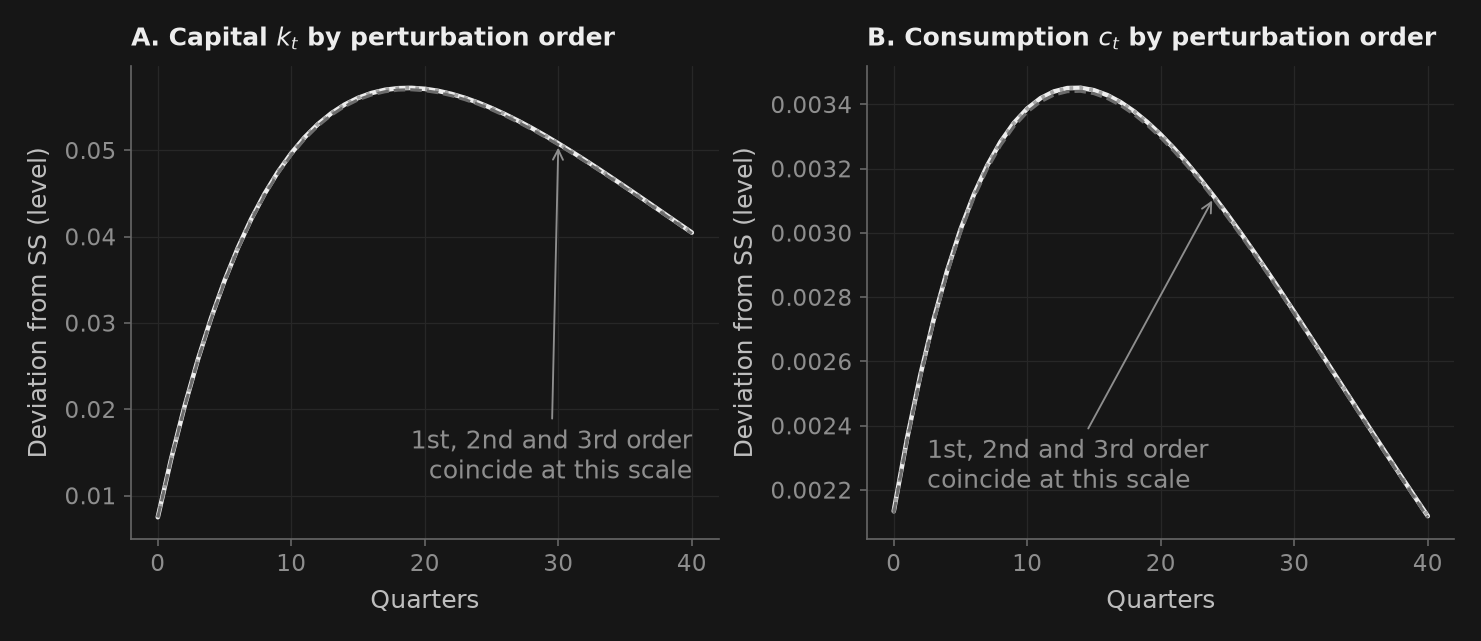

Non-explosive 3rd-order pruned simulation successful: 1000 periods generated.
2nd-Order Perturbation Invariants: PASSED (Spectral radius: 0.9512, ghxx max: 1.4814)
2nd- and 3rd-order perturbation with pruning assertions successfully passed!


In [4]:
# ==============================================================================
# 2nd-Order Perturbation with Pruning Laboratory (Kim et al. 2008)
# ==============================================================================
sol2 = m_rbc.solve(order=2)
sol3 = m_rbc.solve(order=3)
from puremacro.dsge.pruning import canonical_growth_3rd_order, Order3PrunedSolution

# 1. Solve Canonical Benchmark One-Sector Model to 3rd Order
sol3_bench = canonical_growth_3rd_order()
assert isinstance(sol3_bench, Order3PrunedSolution), "Benchmark must return Order3PrunedSolution."
print("=" * 76)
print("CANONICAL GROWTH 3RD-ORDER BENCHMARK (Andreasen et al. 2018)")
print("=" * 76)
print(f"Benchmark State Variables    : {sol3_bench.states}")
print(f"Benchmark Control Variables  : {sol3_bench.controls}")
print(f"3rd-Order Tensor ghxxx Shape : {sol3_bench.ghxxx.shape}")
print(f"Risk-State Drift ghxss Shape : {sol3_bench.ghxss.shape}")

# 2. Solve 8-Variable Canonical RBC Model to 2nd and 3rd Order
assert isinstance(sol3, Order3PrunedSolution), "Canonical RBC 3rd order must return Order3PrunedSolution."

# 3. Precautionary Savings Drift (0.5 * ghs2) & Stochastic Steady State
sss2 = sol2.stochastic_steady_state()
sss3 = sol3.stochastic_steady_state()

ss_comp = pd.DataFrame({
    "Deterministic SS": m_rbc.steady_state,
    "2nd-Order Shift": pd.concat([sss2["controls"], sss2["states"]]).reindex(m_rbc.variables),
    "3rd-Order Shift": pd.concat([sss3["controls"], sss3["states"]]).reindex(m_rbc.variables),
})
ss_comp["Stochastic SS (Level)"] = ss_comp["Deterministic SS"] + ss_comp["3rd-Order Shift"]
ss_comp["Precautionary Premium (%)"] = 100.0 * ss_comp["3rd-Order Shift"] / ss_comp["Deterministic SS"]

print("\nDETERMINISTIC VS. STOCHASTIC STEADY STATE (Precautionary Effects):")
print(ss_comp[["Deterministic SS", "Stochastic SS (Level)", "Precautionary Premium (%)"]].round(5))

# 4. Generalized Impulse Response Functions (1st vs 2nd vs 3rd Order)
irf_lin = m_rbc.irf("e_a", horizon=40, size=0.007)
girf2 = sol2.girf("e_a", horizon=40, size=0.007)
girf3 = sol3.girf("e_a", horizon=40, size=0.007)

fig, (ax_k, ax_c) = _nbstyle.figura(1, 2)
h_axis = np.arange(len(girf3))

ax_k.plot(h_axis, girf3["k"], color=_nbstyle.UNIVERSAL_COLORS[0], lw=2.2, ls="-")
ax_k.plot(h_axis, girf2["k"], color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.8, ls=":")
ax_k.plot(h_axis, irf_lin["k"], color=_nbstyle.UNIVERSAL_COLORS[2], lw=1.5, ls="--")
ax_k.set_title("A. Capital $k_t$ by perturbation order")
ax_k.set_xlabel("Quarters")
ax_k.set_ylabel("Deviation from SS (level)")

ax_c.plot(h_axis, girf3["c"], color=_nbstyle.UNIVERSAL_COLORS[0], lw=2.2, ls="-")
ax_c.plot(h_axis, girf2["c"], color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.8, ls=":")
ax_c.plot(h_axis, irf_lin["c"], color=_nbstyle.UNIVERSAL_COLORS[2], lw=1.5, ls="--")
ax_c.set_title("B. Consumption $c_t$ by perturbation order")
ax_c.set_xlabel("Quarters")
ax_c.set_ylabel("Deviation from SS (level)")

# The three responses overlap at this scale: a single note next to the bundle says so
nota_ordenes = "1st, 2nd and 3rd order\ncoincide at this scale"
ax_k.annotate(nota_ordenes, xy=(30, girf3["k"].iloc[30]), xytext=(40, 0.011), ha="right", va="bottom",
              color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_c.annotate(nota_ordenes, xy=(24, girf3["c"].iloc[24]), xytext=(2.5, 0.00218), ha="left", va="bottom",
              color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

plt.show()

# 5. Long Non-Explosive 3-State Pruned Simulation (1,000 Quarters)
sim_pruned3 = sol3.simulate(periods=1000, seed=42)
assert sim_pruned3.controls.shape[0] == 1000, "Simulation period mismatch."
assert not np.isnan(sim_pruned3.controls.to_numpy()).any(), "Pruned simulation contains NaN."
assert not np.isinf(sim_pruned3.controls.to_numpy()).any(), "Pruned simulation diverged (explosive polynomial)."
assert np.abs(sim_pruned3.controls["y"]).max() < 1.0, "Pruned simulation exceeded reasonable bounds."
print(f"Non-explosive 3rd-order pruned simulation successful: {sim_pruned3.controls.shape[0]} periods generated.")

# 6. 2nd-Order Perturbation Mathematical Invariants (Andreasen et al. 2018)
assert sol2.is_stable is True, "2nd-order companion matrix must be stable"
assert sol2.spectral_radius < 1.0, f"Spectral radius {sol2.spectral_radius:.4f} >= 1.0"
assert np.all(np.isfinite(sol2.ghxx)), "2nd-order state curvature tensor ghxx contains non-finite values"
assert np.all(np.isfinite(sol2.ghxu)), "2nd-order state-shock tensor ghxu contains non-finite values"
assert np.all(np.isfinite(sol2.ghuu)), "2nd-order shock curvature tensor ghuu contains non-finite values"
assert np.all(np.isfinite(sol2.ghs2)), "Precautionary drift ghs2 contains non-finite values"
print(f"2nd-Order Perturbation Invariants: PASSED (Spectral radius: {sol2.spectral_radius:.4f}, ghxx max: {np.abs(sol2.ghxx).max():.4f})")
print("2nd- and 3rd-order perturbation with pruning assertions successfully passed!")

## Model vs. Data: The Stylized Facts of US and Mexico

A central pedagogical lesson of **Slides 04 (Slide 341-368)** is that an economic model must be evaluated against empirical business cycle moments. Doing that honestly requires one preliminary step that is easy to skip: **the model has to go through the same pipeline the data went through.** The published stylized facts are standard deviations of the *logarithm* of each series after removing a Hodrick-Prescott trend with $\lambda = 1600$; the moments printed above are unconditional and unfiltered. Comparing the two directly would mean comparing different objects, so before scoring anything we simulate the model, take logs, and apply the same filter (Kydland & Prescott 1982, Cooley & Prescott 1995, King & Rebelo 1999).

Scored that way, the canonical RBC model earns a mixed report card:
- **Consumption Smoothing**: households smooth aggressively across states, yielding $\sigma_c / \sigma_y \approx 0.33$. In US data $\sigma_c / \sigma_y \approx 0.74$, and in **Mexico** consumption is nearly as volatile as output, $\sigma_c / \sigma_y \approx 0.96$. The model over-smoothes consumption by more than a factor of two.
- **Excess Investment Volatility**: capital adjustment and intertemporal substitution make investment the primary shock absorber, producing $\sigma_i / \sigma_y \approx 3.3$. This lands squarely on the stylized fact that investment is 3 to 4 times more volatile than output in both advanced and emerging economies — the model's clearest success.
- **Hours**: $\sigma_l / \sigma_y \approx 0.41$ against $0.86$ in US data. Labor moves far too little, a failure Section 8 takes up directly.
- **Procyclical Labor and Wages**: the model generates strong procyclicality for hours $\text{Corr}(l, y) > 0$ and wages $\text{Corr}(w, y) > 0$.

As noted in Slide 361, fixing the Mexican consumption volatility failure requires either **non-neutral investment shocks** ($q_t$, Greenwood-Hercowitz-Krusell), **trend shocks** (Aguiar & Gopinath 2007), or **financial frictions in small open economies** (Neumeyer & Perri 2005).

BUSINESS CYCLE SCORECARD (model simulated 4000 quarters, logged, HP-filtered at lambda = 1600):
                                 Moment   Canonical RBC Model US Data (1947-2019) Mexico Data (1993-2024)
             Output Volatility sigma(y)                 1.26%               1.58%                   2.14%
Rel. Consumption Vol. sigma(c)/sigma(y) 0.33 (Over-smoothes!)                0.74 0.96 (Fails to smooth!)
 Rel. Investment Vol. sigma(i)/sigma(y)                  3.33                3.12                    3.45
      Rel. Hours Vol. sigma(l)/sigma(y)                  0.41                0.86                    0.78
                 Correlation Corr(c, y)                  0.91                0.82                    0.88
                 Correlation Corr(i, y)                  0.99                0.91                    0.84


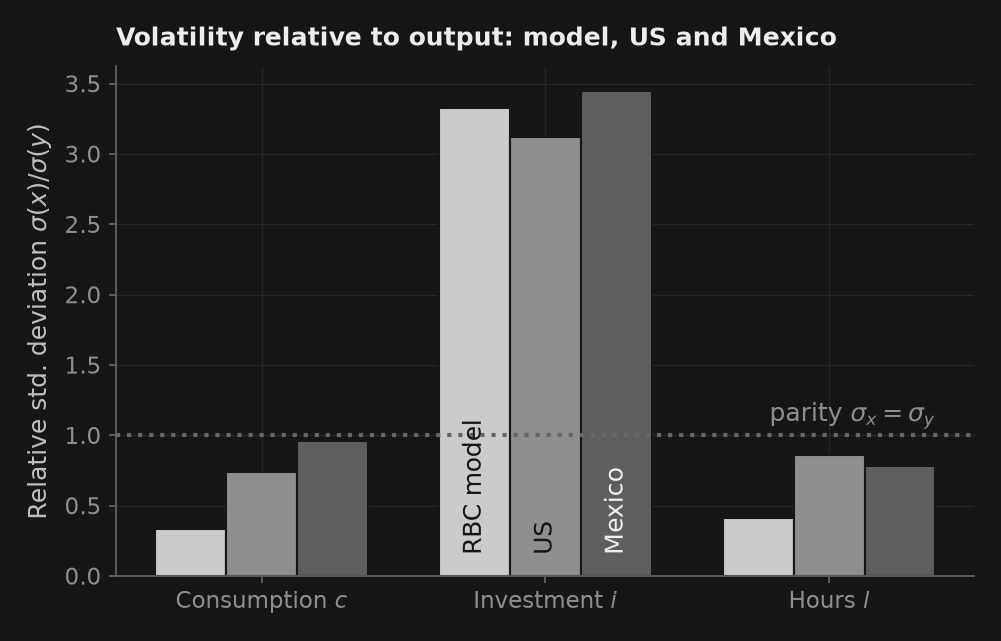

In [5]:
# ==============================================================================
# Scorecard: the Model Put Through the Empirical Pipeline vs. US and Mexico
# ==============================================================================
from puremacro.data import hp_filter

SS_LEVELS = {"y": ss_rbc["y"], "c": ss_rbc["c"], "i": ss_rbc["i"], "l": ss_rbc["l"], "w": ss_rbc["w"]}
T_SIM = 4000


def filtered_cycles(model, periods=T_SIM, seed=20260906, burn=300, sigma=None, levels=None):
    """Simulate, convert level deviations to log points, and HP-filter with lambda = 1600.

    This is the pipeline the published empirical moments come from, so it is the pipeline
    the model has to go through before the two can be laid side by side.
    """
    levels = SS_LEVELS if levels is None else levels
    raw = model.simulate(periods=periods, seed=seed, burn=burn, sigma=sigma)
    logs = {v: 100.0 * np.log((lvl + raw[v].values) / lvl) for v, lvl in levels.items()}
    return pd.DataFrame({v: hp_filter(pd.Series(s), lamb=1600.0)[0].values for v, s in logs.items()})


cyc = filtered_cycles(m_rbc)
sd_cyc = cyc.std()
rel_cyc = sd_cyc / sd_cyc["y"]
corr_cyc = cyc.corrwith(cyc["y"])

scorecard_data = [
    {
        "Moment": "Output Volatility sigma(y)",
        "Canonical RBC Model": f"{sd_cyc['y']:.2f}%",
        "US Data (1947-2019)": "1.58%",
        "Mexico Data (1993-2024)": "2.14%",
    },
    {
        "Moment": "Rel. Consumption Vol. sigma(c)/sigma(y)",
        "Canonical RBC Model": f"{rel_cyc['c']:.2f} (Over-smoothes!)",
        "US Data (1947-2019)": "0.74",
        "Mexico Data (1993-2024)": "0.96 (Fails to smooth!)",
    },
    {
        "Moment": "Rel. Investment Vol. sigma(i)/sigma(y)",
        "Canonical RBC Model": f"{rel_cyc['i']:.2f}",
        "US Data (1947-2019)": "3.12",
        "Mexico Data (1993-2024)": "3.45",
    },
    {
        "Moment": "Rel. Hours Vol. sigma(l)/sigma(y)",
        "Canonical RBC Model": f"{rel_cyc['l']:.2f}",
        "US Data (1947-2019)": "0.86",
        "Mexico Data (1993-2024)": "0.78",
    },
    {
        "Moment": "Correlation Corr(c, y)",
        "Canonical RBC Model": f"{corr_cyc['c']:.2f}",
        "US Data (1947-2019)": "0.82",
        "Mexico Data (1993-2024)": "0.88",
    },
    {
        "Moment": "Correlation Corr(i, y)",
        "Canonical RBC Model": f"{corr_cyc['i']:.2f}",
        "US Data (1947-2019)": "0.91",
        "Mexico Data (1993-2024)": "0.84",
    },
]

scorecard_df = pd.DataFrame(scorecard_data)
print(f"BUSINESS CYCLE SCORECARD (model simulated {T_SIM} quarters, logged, HP-filtered at lambda = 1600):")
print(scorecard_df.to_string(index=False))

# Visualization: Relative Volatilities
fig, ax = _nbstyle.figura(1, 1)
categories = ["Consumption $c$", "Investment $i$", "Hours $l$"]
model_vals = [rel_cyc['c'], rel_cyc['i'], rel_cyc['l']]
us_vals    = [0.74, 3.12, 0.86]
mex_vals   = [0.96, 3.45, 0.78]

x = np.arange(len(categories))
width = 0.25

for j, (nombre, vals) in enumerate((("RBC model", model_vals), ("US", us_vals), ("Mexico", mex_vals))):
    ax.bar(x + (j - 1) * width, vals, width, color=_nbstyle.BARRA_COLORES[j], edgecolor=_nbstyle.FONDO, lw=1)
    # each series is named vertically inside its investment bar (the only one tall enough for the text)
    ax.text(x[1] + (j - 1) * width, 0.15, nombre, rotation=90, ha="center", va="bottom",
            color=_nbstyle.FONDO if j < 2 else _nbstyle.TINTA)

ax.axhline(1.0, color=_nbstyle.SPINE, linestyle=":")
ax.annotate(r"parity $\sigma_x = \sigma_y$", xy=(x[-1] + 1.5 * width, 1.0), xytext=(0, 3), textcoords="offset points",
            ha="right", va="bottom", color=_nbstyle.NOTA)
ax.set_ylabel(r"Relative std. deviation $\sigma(x)/\sigma(y)$")
ax.set_title("Volatility relative to output: model, US and Mexico")
ax.set_xticks(x)
ax.set_xticklabels(categories)

plt.show()

# The Galí (1999) Hours Debate: RBC Theory vs. Empirical SVAR Evidence

Slide 506 of `Slides04mav.tex` highlights the single most famous empirical challenge to the Real Business Cycle model: **Jordi Galí (1999)**, *"Technology, Employment, and the Business Cycle: Do Technology Shocks Explain Aggregate Fluctuations?"* (American Economic Review 89(1), 249-271).

## The Conflict:
1. **The RBC Prediction ($\Delta l_0 > 0$)**: When a positive technology shock hits, the marginal product of labor rises. Because the shock is temporary ($\rho_a = 0.95$), the intertemporal substitution effect dominates the income effect: working today yields a higher real return than working in the future. Consequently, hours worked **rise** on impact.
2. **The Empirical Finding ($\Delta l_0 < 0$)**: Galí estimated a structural VAR on labor productivity growth $\Delta(y_t - l_t)$ and per-capita hours growth $\Delta h_t$, identifying technology shocks via Blanchard-Quah (1989) long-run restrictions (technology is the unique structural shock with a permanent effect on labor productivity). In real US data, hours worked **fall sharply on impact**!

## The Theoretical Resolution:
If nominal prices are sticky (as in New Keynesian models), aggregate demand cannot expand immediately when technology improves. Because each worker is now more productive, firms need fewer labor hours to meet sticky demand, so employment drops.

Below, rather than relying on synthetic approximations, we load the course's empirical dataset `data_curso/gali1999.csv` (OPHNFB labor productivity, HOANBS hours, CNP16OV population) and estimate the exact empirical Blanchard-Quah SVAR via `puremacro.var.identify.bq.bq_svar`.

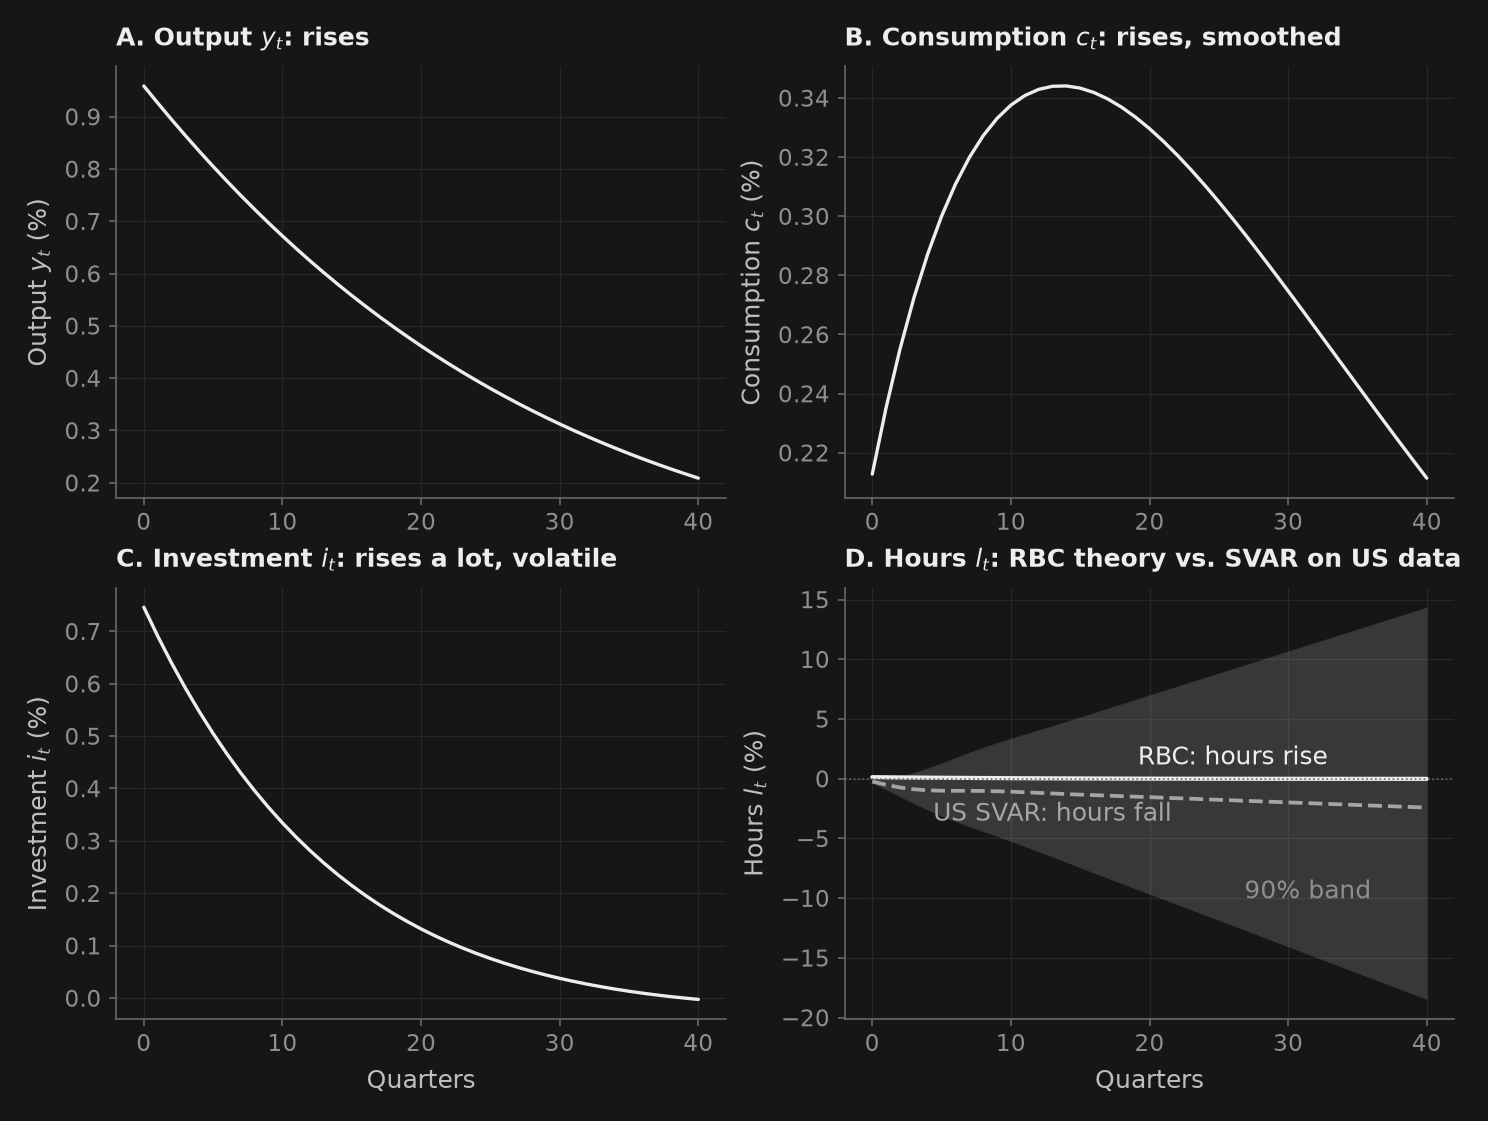

Impact Hours in Canonical RBC : +0.130% (RBC theory predicts expansion)
Impact Hours in Empirical SVAR: -0.233% (Real US data rejects pure RBC mechanism)


In [6]:
# ==============================================================================
# The Galí (1999) Debate: Theoretical RBC IRF vs. Empirical BQ-SVAR
# ==============================================================================
from puremacro.var.identify.bq import bq_svar

# 1. Extract 40-period RBC Model Impulse Responses
irf_rbc = m_rbc.irf("e_a", horizon=40, size=0.007)

# 2. Load Real Empirical Galí (1999) Dataset from data_curso/
gali_csv_path = ruta_dato("gali1999.csv")

df_gali_raw = pd.read_csv(gali_csv_path)
df_gali_raw["date"] = pd.to_datetime(df_gali_raw["date"])
df_gali_raw = df_gali_raw.set_index("date").sort_index()

# Extract pre-Great-Recession sample (1948Q2 to 2007Q4, standard in literature)
sample_gali = df_gali_raw.loc["1948-04-01":"2007-12-31"].copy()
dprod = 100.0 * np.log(sample_gali["ophnfb"]).diff()
h_pc = 100.0 * np.log(sample_gali["hoanbs"] / sample_gali["cnp16ov"])
dh_pc = h_pc.diff()
df_svar = pd.concat({"dprod": dprod, "dh": dh_pc}, axis=1).dropna()

# 3. Estimate Empirical Bivariate Blanchard-Quah SVAR (4 lags, 200 bootstrap draws)
res_bq = bq_svar(df_svar[["dprod", "dh"]].values, p=4, horizon=40, permanent_var_idx=0, n_boot=200, seed=42)

# Technology shock is shock 0; response of variable 1 (dh) cumulated gives hours level h
irf_dh_point = res_bq.irf_point[:, 1, 0]
irf_h_point = np.cumsum(irf_dh_point)
irf_h_lower = np.cumsum(res_bq.irf_lower[:, 1, 0])
irf_h_upper = np.cumsum(res_bq.irf_upper[:, 1, 0])

# 4. Comparative 4-Panel Visualization
fig, axes = _nbstyle.figura(2, 2)

# Panel A: Output
axes[0, 0].plot(irf_rbc.index, irf_rbc["y"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
axes[0, 0].set_title("A. Output $y_t$: rises")
# the axis label names the panel's variable: the slide drops the titles, and without it
# the four panels would not say which is which
axes[0, 0].set_ylabel("Output $y_t$ (%)")

# Panel B: Consumption
axes[0, 1].plot(irf_rbc.index, irf_rbc["c"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
axes[0, 1].set_title("B. Consumption $c_t$: rises, smoothed")
axes[0, 1].set_ylabel("Consumption $c_t$ (%)")

# Panel C: Investment
axes[1, 0].plot(irf_rbc.index, irf_rbc["i"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
axes[1, 0].set_title("C. Investment $i_t$: rises a lot, volatile")
axes[1, 0].set_xlabel("Quarters")
axes[1, 0].set_ylabel("Investment $i_t$ (%)")

# Panel D: Hours Worked -- RBC Theory vs. Real Empirical SVAR
ax_h = axes[1, 1]
h_grid = np.arange(len(irf_h_point))
ax_h.plot(irf_rbc.index, irf_rbc["l"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=2.0, ls="-")
ax_h.plot(h_grid, irf_h_point, color=_nbstyle.S2["color"], linestyle="--", lw=1.8)
ax_h.fill_between(h_grid, irf_h_lower, irf_h_upper, color=_nbstyle.BANDA, lw=0)
ax_h.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
# each line is named inside the panel and at a different x, so the labels neither collide
# nor spill out of the frame when the figure is drawn at slide-slot size
ax_h.annotate("RBC: hours rise", xy=(26, irf_rbc["l"].iloc[26] * 100), xytext=(0, 4),
              textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TINTA)
ax_h.annotate("US SVAR: hours fall", xy=(13, irf_h_point[13]), xytext=(0, -4),
              textcoords="offset points", ha="center", va="top", color=_nbstyle.S2["color"])
ax_h.text(36, (irf_h_lower[36] + irf_h_point[36]) / 2, "90% band", ha="right", va="center", color=_nbstyle.NOTA)
ax_h.set_title("D. Hours $l_t$: RBC theory vs. SVAR on US data")
ax_h.set_xlabel("Quarters")
ax_h.set_ylabel("Hours $l_t$ (%)")

plt.show()

# Verification Assertions
assert irf_rbc.loc[0, "l"] > 0.0, "Theoretical RBC failure: Labor supply response to TFP must be positive on impact."
assert irf_dh_point[0] < 0.0, "Empirical SVAR failure: US hours worked must fall on impact of technology shock."
print(f"Impact Hours in Canonical RBC : +{irf_rbc.loc[0, 'l']*100:.3f}% (RBC theory predicts expansion)")
print(f"Impact Hours in Empirical SVAR: {irf_dh_point[0]:.3f}% (Real US data rejects pure RBC mechanism)")

## Frisch Elasticity Sensitivity Laboratory & Hansen Indivisible Labor RBC

Slide 540 of `Slides04mav.tex` analyzes the sensitivity of the model to the labor curvature parameter $\nu$. The Frisch elasticity of labor supply is defined as:
$$ \eta_{\text{Frisch}} = \frac{1 - l}{\nu \cdot l} $$

- **The Micro-Macro Elasticity Conflict**:
  - **Microeconometric panel studies** (e.g. MaCurdy 1981, Altonji 1986) track individual prime-age wage earners along the intensive margin and consistently estimate $\eta \approx 0.2 - 0.5$ ($\nu \approx 4 - 10$).
  - **Macroeconomic RBC calibrations** require high aggregate elasticity $\eta \ge 2.0$ ($\nu \le 1.0$) to generate hours volatility close to output volatility.
- **Hansen (1985) and Rogerson (1988) Indivisible Labor**: In real life, individuals work full-time or zero hours (the extensive margin). Employment lotteries aggregate heterogeneous individuals into a representative utility function that is **linear in hours** ($\nu \to 0$):
  $$ U(C_t, L_t) = \ln C_t - B L_t $$
  This yields an **infinite macro Frisch elasticity** from a low micro elasticity, drastically amplifying hours volatility without requiring unrealistic individual preferences.

Below, we perform a sensitivity sweep across $\nu \in [0.2, 0.5, 1.0, 2.0, 5.0]$ and explicitly solve the structural **Hansen (1985) Indivisible Labor RBC model** ($\nu=0.0$).

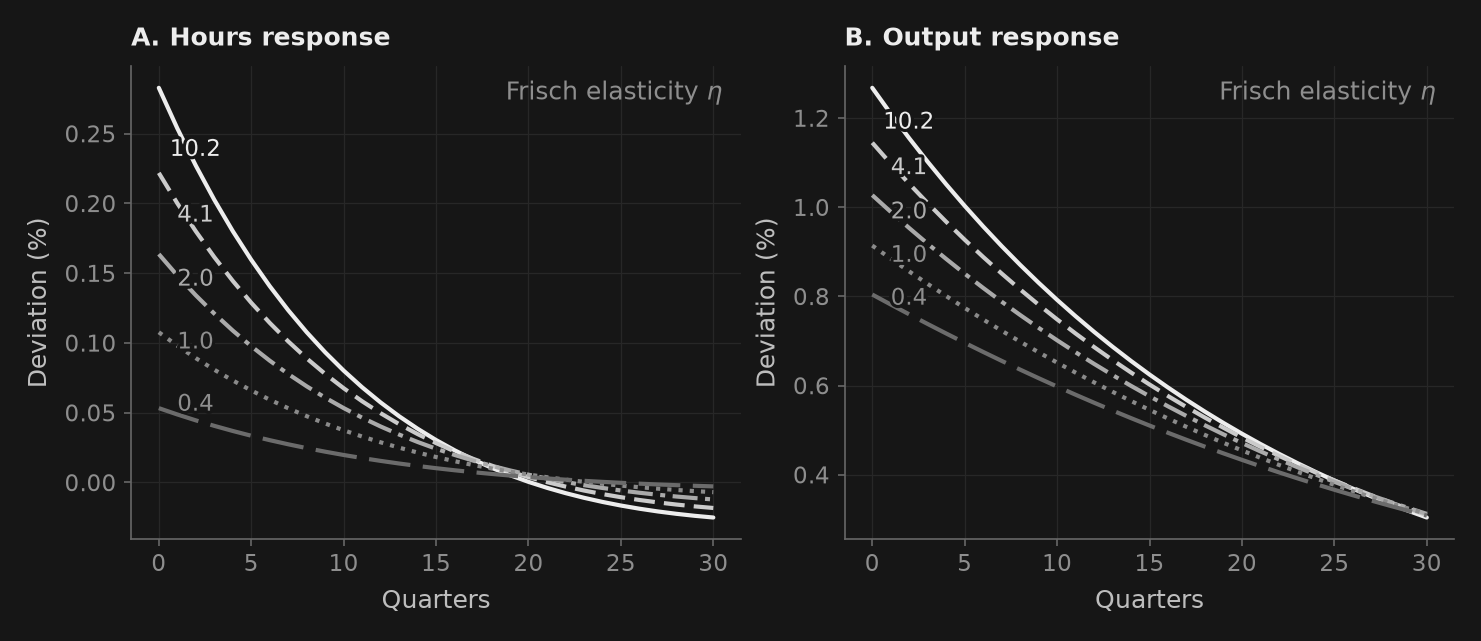

FRISCH ELASTICITY SENSITIVITY TABLE:
 nu (Curvature)  Implied Frisch eta  Hours Impact dl/dea  Output Impact dy/dea               Interpretation
            0.2               10.15               0.4040                1.8112 Indivisible labor (Rogerson)
            0.5                4.06               0.3169                1.6353 Indivisible labor (Rogerson)
            1.0                2.03               0.2338                1.4674               Standard Macro
            2.0                1.02               0.1538                1.3057   Microeconometric (MaCurdy)
            5.0                0.41               0.0761                1.1488   Microeconometric (MaCurdy)

HANSEN (1985) INDIVISIBLE LABOR RBC MODEL RESULTS (nu = 0.0):
Impact Hours Response dl/dea          : 0.4960 (Amplification: 6.52x vs. micro nu=5.0)
Theoretical sigma(l) / sigma(y)       : 0.170 (US empirical data target: 0.860)
Hansen indivisible labor assertions successfully passed!


In [7]:
# ==============================================================================
# Frisch Sensitivity Sweep across nu & Hansen (1985) Indivisible Labor Model
# ==============================================================================
nu_sweep_vals = [0.2, 0.5, 1.0, 2.0, 5.0]
sweep_results = []

fig, (ax_l_sweep, ax_y_sweep) = _nbstyle.figura(1, 2)

nu_colors, nu_dashes = _nbstyle.palette(len(nu_sweep_vals)), _nbstyle.styles(len(nu_sweep_vals))
for nu_v, nu_col, nu_ls in zip(nu_sweep_vals, nu_colors, nu_dashes):
    # Recalibrate mu to keep steady state hours at 0.33
    ss_v = solve_canonical_rbc_ss(nu=nu_v, l_target=0.33)
    # Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
        m_v = load_mod(rbc_mod_path, params={"nu": nu_v, "mu": ss_v["mu"]})
    
    frisch_eta = (1.0 - 0.33) / (0.33 * nu_v)
    dr_v = m_v.decision_rules().to_frame()
    dl_dea = dr_v.loc["e_a", "l"]
    dy_dea = dr_v.loc["e_a", "y"]
    
    irf_v = m_v.irf("e_a", horizon=30, size=0.007)
    
    label_str = f"{frisch_eta:.1f}"
    ax_l_sweep.plot(irf_v.index, irf_v["l"] * 100, color=nu_col, ls=nu_ls, label=label_str)
    ax_y_sweep.plot(irf_v.index, irf_v["y"] * 100, color=nu_col, ls=nu_ls, label=label_str)
    
    sweep_results.append({
        "nu (Curvature)": nu_v,
        "Implied Frisch eta": round(frisch_eta, 2),
        "Hours Impact dl/dea": round(dl_dea, 4),
        "Output Impact dy/dea": round(dy_dea, 4),
        "Interpretation": "Indivisible labor (Rogerson)" if nu_v <= 0.5 else ("Standard Macro" if nu_v <= 1.5 else "Microeconometric (MaCurdy)")
    })

ax_l_sweep.set_title("A. Hours response")
ax_l_sweep.set_xlabel("Quarters")
ax_l_sweep.set_ylabel("Deviation (%)")

ax_y_sweep.set_title("B. Output response")
ax_y_sweep.set_xlabel("Quarters")
ax_y_sweep.set_ylabel("Deviation (%)")

# No legend: the responses fan out on impact, and right there, where the fan is
# widest, each curve carries its own elasticity beside it. A note in the empty
# upper-right corner the five curves leave free says what those numbers are,
# which keeps the titles to a single line at slide width.
for ax in (ax_l_sweep, ax_y_sweep):
    _nbstyle.etiquetar(ax, donde=2.0)
    ax.annotate("Frisch elasticity $\\eta$", xy=(0.97, 0.97),
                xycoords="axes fraction", ha="right", va="top", color=_nbstyle.NOTA)

plt.show()

sweep_df = pd.DataFrame(sweep_results)
print("FRISCH ELASTICITY SENSITIVITY TABLE:")
print(sweep_df.to_string(index=False))

# 2. Structural Hansen (1985) Indivisible Labor RBC (nu = 0.0)
ss_hansen = solve_canonical_rbc_ss(nu=0.0, l_target=0.33)
m_hansen = load_mod(rbc_mod_path, params={"nu": 0.0, "mu": ss_hansen["mu"]})
assert m_hansen.solution.eu == (1, 1), "Hansen RBC model must have unique saddle-path equilibrium."

dr_hansen = m_hansen.decision_rules().to_frame()
dl_hansen = dr_hansen.loc["e_a", "l"]
sim_hansen = m_hansen.stoch_simul(order=1, irf=40)
tm_hansen = sim_hansen.theoretical_moments.moments

dl_micro = sweep_df.loc[sweep_df["nu (Curvature)"] == 5.0, "Hours Impact dl/dea"].values[0]

rel_hours_vol_hansen = tm_hansen.loc["l", "Std.Dev."] / tm_hansen.loc["y", "Std.Dev."]

print("\n" + "=" * 76)
print("HANSEN (1985) INDIVISIBLE LABOR RBC MODEL RESULTS (nu = 0.0):")
print("=" * 76)
print(f"Impact Hours Response dl/dea          : {dl_hansen:.4f} (Amplification: {dl_hansen/dl_micro:.2f}x vs. micro nu=5.0)")
print(f"Theoretical sigma(l) / sigma(y)       : {rel_hours_vol_hansen:.3f} (US empirical data target: 0.860)")
print("=" * 76)

assert dl_hansen > 3.0 * dl_micro, f"Indivisible labor should multiply hours response by > 3x: {dl_hansen:.4f} vs {dl_micro:.4f}"
print("Hansen indivisible labor assertions successfully passed!")

## Multi-Shock RBC & Variance Decomposition (FEVD)

In a single-shock RBC model, 100% of the variance is trivially attributed to neutral TFP. However, **Slides 04 (Slides 680-720)** introduce non-neutral technology shocks: **Investment-Specific Technical Change ($q_t$)** (Greenwood, Hercowitz & Krusell 1997, Fisher 2006):
$$ k_t = (1-\delta)k_{t-1} + e^{q_t} i_t $$

Here, $q_t$ represents the inverse of the relative price of equipment investment ($1 / P_{I,t}$). When technology makes computer chips and machine tools cheaper, capital accumulation surges without an immediate increase in current consumption goods productivity.

By estimating the joint model with both neutral TFP ($a_t$) and investment shocks ($q_t$), we compute the **Forecast Error Variance Decomposition (FEVD)** using `LinearModel.fevd_result`:
- How much of short-run business cycles is driven by investment shocks vs. Solow residuals?
- Does $q_t$ explain the volatile investment and consumption behavior observed in Mexican and US data?

NATIVE FEVD RESULT TABLE (FEVDResult.table - Output & Investment):
                    e_a    e_q
Variable Horizon              
y        1        83.27  16.73
         4        91.24   8.76
         8        94.43   5.57
         16       96.23   3.77
         40       97.13   2.87
i        1        37.93  62.07
         4        57.53  42.47
         8        67.39  32.61
         16       72.23  27.77
         40       73.17  26.83


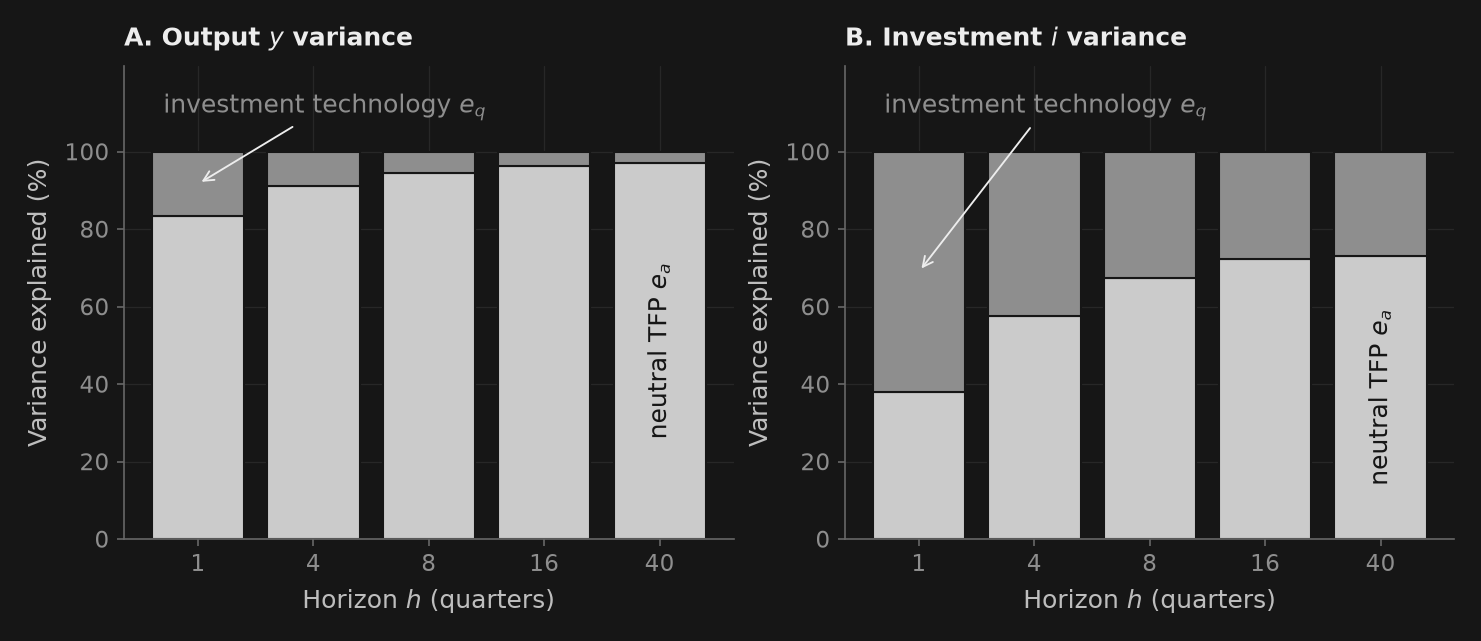

FORECAST ERROR VARIANCE DECOMPOSITION (Output vs. Investment):
Horizon Output: TFP (e_a) Output: IST (e_q) Investment: TFP (e_a) Investment: IST (e_q)
    h=1             83.3%             16.7%                 37.9%                 62.1%
    h=4             91.2%              8.8%                 57.5%                 42.5%
    h=8             94.4%              5.6%                 67.4%                 32.6%
   h=16             96.2%              3.8%                 72.2%                 27.8%
   h=40             97.1%              2.9%                 73.2%                 26.8%
All multi-shock variance decomposition assertions passed successfully!


In [8]:
# ==============================================================================
# Multi-Shock RBC Model: Neutral TFP (a) + Investment-Specific Tech (q)
# ==============================================================================
multi_shock_mod = """
var y c k l i w r a q;
varexo e_a e_q;

parameters alpha beta delta mu nu rho_a rho_q sigma_a sigma_q;
alpha   = 0.33;
beta    = 0.99;
delta   = 0.025;
mu      = 0.822516;
nu      = 1.5;
rho_a   = 0.95;
rho_q   = 0.60;
sigma_a = 0.007;
sigma_q = 0.008;

model;
mu * (1 - l)^(-nu) * c = w;
c(+1)/(beta*c) = (r(+1) + (1-delta)/exp(q(+1))) * exp(q);
r = alpha * y / k(-1);
w = (1 - alpha) * y / l;
y = exp(a) * k(-1)^alpha * l^(1-alpha);
y = c + i;
k = (1 - delta)*k(-1) + exp(q)*i;
a = rho_a * a(-1) + e_a;
q = rho_q * q(-1) + e_q;
end;

initval;
y = 0.995;
c = 0.761;
i = 0.234;
k = 9.355;
l = 0.330;
w = 2.020;
r = 0.035;
a = 0.0;
q = 0.0;
end;

shocks;
var e_a; stderr 0.007;
var e_q; stderr 0.008;
end;
"""

# Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_multi = load_mod(multi_shock_mod, params={"mu": ss_rbc["mu"]})

# Extract analytical FEVD table via native puremacro FEVDResult API
horizons = [1, 4, 8, 16, 40]
fevd_res = m_multi.fevd_result(horizons=horizons)
fevd_df = fevd_res.to_frame() * 100.0  # Convert fractional shares to percentages

print("NATIVE FEVD RESULT TABLE (FEVDResult.table - Output & Investment):")
print((fevd_res.table.loc[["y", "i"]] * 100.0).round(2))

y_fevd_a = [fevd_df.loc[("y", h), "e_a"] for h in horizons if ("y", h) in fevd_df.index]
y_fevd_q = [fevd_df.loc[("y", h), "e_q"] for h in horizons if ("y", h) in fevd_df.index]
i_fevd_a = [fevd_df.loc[("i", h), "e_a"] for h in horizons if ("i", h) in fevd_df.index]
i_fevd_q = [fevd_df.loc[("i", h), "e_q"] for h in horizons if ("i", h) in fevd_df.index]

fig, (ax_y_fevd, ax_i_fevd) = _nbstyle.figura(1, 2)

h_labels = [f"h={h}" for h in horizons[:len(y_fevd_a)]]
x_pos = np.arange(len(h_labels))

for ax, fevd_a, fevd_q, titulo in ((ax_y_fevd, y_fevd_a, y_fevd_q, "A. Output $y$ variance"),
                                    (ax_i_fevd, i_fevd_a, i_fevd_q, "B. Investment $i$ variance")):
    ax.bar(x_pos, fevd_a, color=_nbstyle.BARRA_COLORES[0], edgecolor=_nbstyle.FONDO, lw=1)
    ax.bar(x_pos, fevd_q, bottom=fevd_a, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=1)
    # the segments are named on the bars themselves: TFP inside the last one, the investment shock with an arrow from above
    ax.text(x_pos[-1], fevd_a[-1] / 2, "neutral TFP $e_a$", rotation=90, ha="center", va="center", color=_nbstyle.FONDO)
    # the leader ends inside the gray segment: it is drawn in the theme's ink (the gray note
    # color was lost on the bar's own gray and seemed to point at the gap between bars)
    ax.annotate("investment technology $e_q$", xy=(x_pos[0], fevd_a[0] + fevd_q[0] / 2), xytext=(x_pos[0] - 0.3, 108),
                ha="left", va="bottom", color=_nbstyle.NOTA,
                arrowprops=dict(_nbstyle.FLECHA, color=_nbstyle.TINTA))
    ax.set_ylim(0, 122)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_title(titulo)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(h) for h in horizons[:len(fevd_a)]])
    ax.set_xlabel("Horizon $h$ (quarters)")
    ax.set_ylabel("Variance explained (%)")

plt.show()

print("FORECAST ERROR VARIANCE DECOMPOSITION (Output vs. Investment):")
summary_fevd = pd.DataFrame({
    "Horizon": h_labels,
    "Output: TFP (e_a)": [f"{v:.1f}%" for v in y_fevd_a],
    "Output: IST (e_q)": [f"{v:.1f}%" for v in y_fevd_q],
    "Investment: TFP (e_a)": [f"{v:.1f}%" for v in i_fevd_a],
    "Investment: IST (e_q)": [f"{v:.1f}%" for v in i_fevd_q],
})
print(summary_fevd.to_string(index=False))

# Assertions
assert y_fevd_a[0] > 50.0, "TFP must explain majority of short-run output variance."
assert i_fevd_q[0] > 50.0, "Investment shock must explain majority of short-run investment variance."
print("All multi-shock variance decomposition assertions passed successfully!")

## The Cyclical Anatomy the Scorecard Cannot Show

The scorecard in Section 3 compares six numbers. A business cycle is more than six numbers, and two of the model's most telling failures are invisible in a table of volatilities. This section looks at the same filtered simulation from two other angles.

**Timing.** The **cross-correlogram** $\mathrm{corr}(x_{t+k}, y_t)$ traces how each series lines up with output at leads and lags — the object Kydland and Prescott used to argue that the model reproduced not just the size of fluctuations but their choreography. Together with the first-order autocorrelations it says whether the model's cycles have the right persistence, or merely the right amplitude.

**The third failure.** With a **single** technology shock, hours and labor productivity are driven by the same impulse, so the model produces $\mathrm{corr}(l, y/l) \approx +0.94$. In US data that correlation is essentially zero (Christiano & Eichenbaum 1992). This is arguably a sharper rejection than any volatility ratio: it is not that the model gets a magnitude wrong, it is that it makes labor and productivity nearly the same variable. Section 8 takes it up and shows that the same repair fixes the hours-volatility shortfall at the same time.

MODEL MOMENTS UNDER THE EMPIRICAL PIPELINE (log deviations, HP lambda = 1600):
   sigma(x) in %  sigma(x)/sigma(y)  corr(x, y)  Autocorr(1)
y          1.261              1.000       1.000        0.717
c          0.420              0.333       0.906        0.803
i          4.195              3.325       0.989        0.706
l          0.516              0.409       0.980        0.705
w          0.761              0.604       0.991        0.737

Simulated sample: 4000 quarters (1000 years). US output autocorrelation is about 0.85.


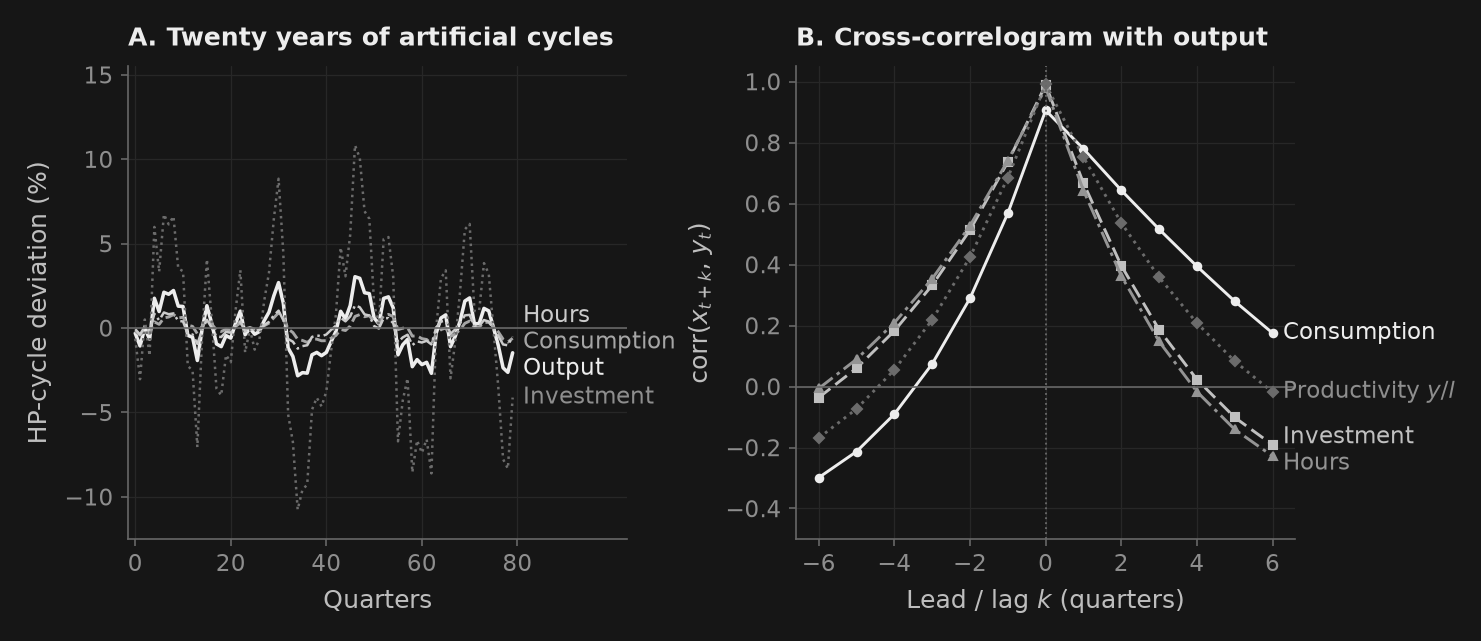


THE THREE CANONICAL FAILURES, MEASURED:
  1. Consumption too smooth : model 0.33 vs. US 0.74  (the model smooths 2.2x too much)
  2. Hours too stable       : model 0.41 vs. US 0.86
  3. Hours and productivity : corr(l, y/l) = +0.94 in the model vs. roughly 0 in US data
  Investment volatility, by contrast, is right: model 3.33 vs. US 3.12

Cyclical-anatomy assertions passed.


In [9]:
# ==============================================================================
# Cross-Correlogram, Persistence, and the Hours-Productivity Correlation
# ==============================================================================
cyc["prod"] = cyc["y"] - cyc["l"]          # labor productivity, y/l in log points

persistence = pd.DataFrame({
    "sigma(x) in %": sd_cyc[["y", "c", "i", "l", "w"]].round(3),
    "sigma(x)/sigma(y)": rel_cyc[["y", "c", "i", "l", "w"]].round(3),
    "corr(x, y)": corr_cyc[["y", "c", "i", "l", "w"]].round(3),
    "Autocorr(1)": cyc[["y", "c", "i", "l", "w"]].apply(lambda s: s.autocorr(1)).round(3),
})
us_targets = {"y": 1.58, "c": 0.74, "i": 3.12, "l": 0.86, "w": 0.58}

print("MODEL MOMENTS UNDER THE EMPIRICAL PIPELINE (log deviations, HP lambda = 1600):")
print(persistence.to_string())
print(f"\nSimulated sample: {T_SIM} quarters ({T_SIM/4:.0f} years). US output autocorrelation is about 0.85.")

# Cross-correlogram: corr(x_{t+k}, y_t) for k = -6 ... +6
leads = np.arange(-6, 7)
ccf = {}
for v in ("c", "i", "l", "prod"):
    ccf[v] = [cyc[v].shift(-k).corr(cyc["y"]) for k in leads]

fig, (ax_path, ax_ccf) = _nbstyle.figura(1, 2)

# Panel A: a 20-year window of artificial data
window = slice(400, 480)
ax_path.plot(np.arange(80), cyc["y"].values[window], color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.7, ls="-", label="Output")
ax_path.plot(np.arange(80), cyc["c"].values[window], color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.4, ls="--", label="Consumption")
ax_path.plot(np.arange(80), cyc["i"].values[window], color=_nbstyle.UNIVERSAL_COLORS[2], lw=1.2, ls=":", label="Investment")
ax_path.plot(np.arange(80), cyc["l"].values[window], color=_nbstyle.UNIVERSAL_COLORS[3], lw=1.2, ls="-.", label="Hours")
ax_path.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_path.set_ylim(-12.5, 15.5)
ax_path.set_xlim(-1.5, 103)          # room on the right for the names, past the last quarter
ax_path.set_xticks(np.arange(0, 81, 20))
ax_path.set_title("A. Twenty years of artificial cycles")
ax_path.set_xlabel("Quarters")
ax_path.set_ylabel("HP-cycle deviation (%)")
_nbstyle.etiquetar(ax_path, donde="fin", fuera=True)

# Panel B: cross-correlogram against output
markers = {"c": "o", "i": "s", "l": "^", "prod": "D"}
labels = {"c": "Consumption", "i": "Investment", "l": "Hours", "prod": "Productivity $y/l$"}
colores_ccf = _nbstyle.palette(4)
for j, v in enumerate(("c", "i", "l", "prod")):
    ax_ccf.plot(leads, ccf[v], color=colores_ccf[j], lw=1.4, marker=markers[v], markersize=3.6, label=labels[v])
ax_ccf.axvline(0, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_ccf.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_ccf.set_ylim(-0.5, 1.05)
ax_ccf.set_title("B. Cross-correlogram with output")
ax_ccf.set_xlabel("Lead / lag $k$ (quarters)")
ax_ccf.set_ylabel(r"corr($x_{t+k}$, $y_t$)")
_nbstyle.etiquetar(ax_ccf, donde="fin")

plt.show()

corr_l_prod = float(cyc["l"].corr(cyc["prod"]))
print("\nTHE THREE CANONICAL FAILURES, MEASURED:")
print(f"  1. Consumption too smooth : model {rel_cyc['c']:.2f} vs. US {us_targets['c']:.2f}  "
      f"(the model smooths {us_targets['c']/rel_cyc['c']:.1f}x too much)")
print(f"  2. Hours too stable       : model {rel_cyc['l']:.2f} vs. US {us_targets['l']:.2f}")
print(f"  3. Hours and productivity : corr(l, y/l) = {corr_l_prod:+.2f} in the model vs. roughly 0 in US data")
print(f"  Investment volatility, by contrast, is right: model {rel_cyc['i']:.2f} vs. US {us_targets['i']:.2f}")

assert 1.0 < sd_cyc["y"] < 1.8, f"HP-filtered output volatility should be near the US 1.58%, got {sd_cyc['y']:.2f}%."
assert rel_cyc["i"] > 2.5, "Investment must be far more volatile than output."
assert rel_cyc["c"] < 0.5, "The canonical RBC model must over-smooth consumption relative to the data."
assert corr_l_prod > 0.8, "With a single technology shock, hours and productivity must move together."
print("\nCyclical-anatomy assertions passed.")

## Two Puzzles, One Missing Shock: A Labor-Supply Disturbance

The previous section left two failures on the table, and they are not independent. With a **single** technology shock, hours and labor productivity are driven by the same impulse, so the model mechanically produces $\mathrm{corr}(l, y/l) \approx +0.94$ — while in US data that correlation is essentially zero (Christiano & Eichenbaum 1992). And because hours only move when technology moves, they inherit technology's modest volatility.

Christiano & Eichenbaum's diagnosis is that a second impulse is missing: something that shifts **labor supply** independently of productivity. They used government spending; the cleanest version for this model is a preference shock $\chi_t$ in the intratemporal condition,
$$ \mu\, e^{\chi_t}\,(1 - l_t)^{-\nu} c_t = w_t, \qquad \chi_t = \rho_\chi \chi_{t-1} + \varepsilon_{\chi,t}, $$
which raises the marginal value of leisure and pushes hours down along a given labor-demand schedule. Crucially, $\chi_{ss} = 0$, so the steady state — and therefore the calibrated $\mu$ — is untouched: nothing else in the model moves.

The experiment sweeps the volatility $\sigma_\chi$ of that shock and asks a single quantitative question: **is there one value that fixes both puzzles at once?** If the same $\sigma_\chi$ that drives $\mathrm{corr}(l, y/l)$ to zero also delivers $\sigma_l/\sigma_y \approx 0.86$, then the two "failures" of the RBC model were one failure — a missing shock, not a broken mechanism.

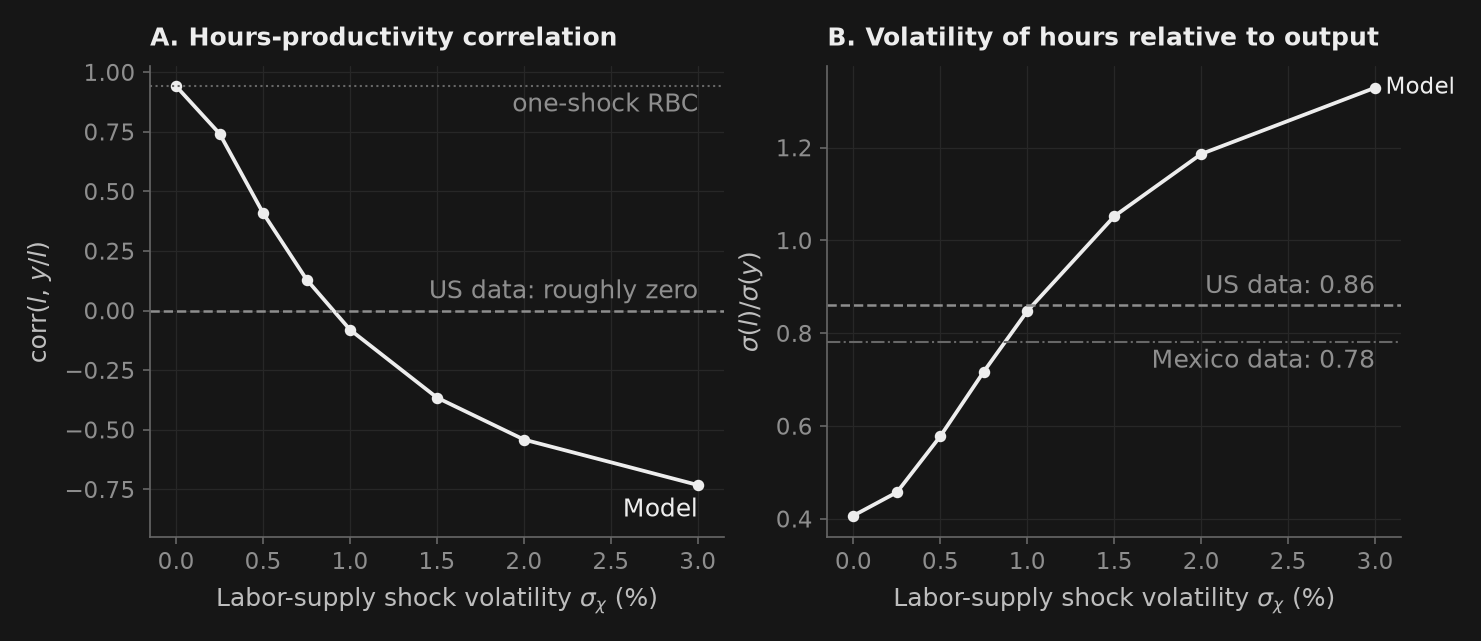

LABOR-SUPPLY SHOCK SWEEP (HP-filtered, 2,000 quarters per run):
 sigma_chi  sigma(y) %  sigma(l)/sigma(y)  sigma(c)/sigma(y)  corr(l, y/l)  corr(l, y)
     0.000       1.230              0.407              0.336         0.941       0.979
     0.002       1.238              0.457              0.334         0.742       0.912
     0.005       1.272              0.578              0.329         0.409       0.829
     0.008       1.332              0.717              0.322         0.130       0.797
     0.010       1.414              0.848              0.314        -0.081       0.799
     0.015       1.630              1.052              0.299        -0.365       0.838
     0.020       1.895              1.186              0.287        -0.541       0.877
     0.030       2.509              1.329              0.272        -0.732       0.928

corr(l, y/l) crosses zero at sigma_chi = 0.90%.
At that same volatility the model delivers sigma(l)/sigma(y) = 0.80 against the US 0.86.
Technology then

In [10]:
# ==============================================================================
# Adding a Labor-Supply (Preference) Shock: chi_t in the Intratemporal Condition
# ==============================================================================
labor_shock_mod = f"""
var y c k l i w r a chi;
varexo e_a e_chi;

parameters alpha beta delta mu nu rho_a rho_chi;
alpha   = 0.33;
beta    = 0.99;
delta   = 0.025;
mu      = {ss_rbc['mu']!r};
nu      = 1.5;
rho_a   = 0.95;
rho_chi = 0.90;

model;
mu * exp(chi) * (1 - l)^(-nu) * c = w;
c(+1)/(beta*c) = r(+1) + 1 - delta;
r = alpha * y / k(-1);
w = (1 - alpha) * y / l;
y = exp(a) * k(-1)^alpha * l^(1-alpha);
y = c + i;
k = (1 - delta)*k(-1) + i;
a = rho_a * a(-1) + e_a;
chi = rho_chi * chi(-1) + e_chi;
end;

initval;
y = {ss_rbc['y']!r};
c = {ss_rbc['c']!r};
i = {ss_rbc['i']!r};
k = {ss_rbc['k']!r};
l = {ss_rbc['l']!r};
w = {ss_rbc['w']!r};
r = {ss_rbc['r']!r};
a = 0.0;
chi = 0.0;
end;

shocks;
var e_a;   stderr 0.007;
var e_chi; stderr 0.010;
end;
"""

# Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_chi = load_mod(labor_shock_mod)
assert m_chi.solution.eu == (1, 1), "The two-shock RBC must retain a unique stable equilibrium."

sigma_chi_grid = np.array([0.0, 0.0025, 0.005, 0.0075, 0.010, 0.015, 0.020, 0.030])
chi_rows = []
for sd_chi in sigma_chi_grid:
    cyc_chi = filtered_cycles(m_chi, periods=2000, seed=4242, sigma={"e_a": 0.007, "e_chi": float(sd_chi)})
    cyc_chi["prod"] = cyc_chi["y"] - cyc_chi["l"]
    s_chi = cyc_chi.std()
    chi_rows.append({
        "sigma_chi": sd_chi,
        "sigma(y) %": s_chi["y"],
        "sigma(l)/sigma(y)": s_chi["l"] / s_chi["y"],
        "sigma(c)/sigma(y)": s_chi["c"] / s_chi["y"],
        "corr(l, y/l)": cyc_chi["l"].corr(cyc_chi["prod"]),
        "corr(l, y)": cyc_chi["l"].corr(cyc_chi["y"]),
    })
chi_df = pd.DataFrame(chi_rows)

# Share of the variance of hours attributable to technology at the baseline sigma_chi = 0.01
fevd_chi = m_chi.fevd(horizons=(1, 4, 8, None), sigma={"e_a": 0.007, "e_chi": 0.010})
tech_share_l = float(fevd_chi.xs("l", level="Variable")["e_a"].iloc[-1])   # last row = unconditional horizon

fig, (ax_corr, ax_vol) = _nbstyle.figura(1, 2)
x_der = float(chi_df["sigma_chi"].max() * 100)   # right edge of the reference labels

# Panel A: the hours-productivity correlation
ax_corr.plot(chi_df["sigma_chi"] * 100, chi_df["corr(l, y/l)"], color=_nbstyle.UNIVERSAL_COLORS[0],
             lw=1.8, ls="-", marker="o", markersize=4.5)
ax_corr.axhline(0.0, color=_nbstyle.NOTA, ls="--", lw=1.2)
ax_corr.axhline(chi_df["corr(l, y/l)"].iloc[0], color=_nbstyle.SPINE, ls=":", lw=1.0)
ax_corr.annotate("Model", xy=(x_der, chi_df["corr(l, y/l)"].iloc[-1]), xytext=(0, -6), textcoords="offset points",
                 ha="right", va="top", color=_nbstyle.TINTA)
ax_corr.annotate("US data: roughly zero", xy=(x_der, 0.0), xytext=(0, 3), textcoords="offset points",
                 ha="right", va="bottom", color=_nbstyle.NOTA)
ax_corr.annotate("one-shock RBC", xy=(x_der, chi_df["corr(l, y/l)"].iloc[0]), xytext=(0, -3), textcoords="offset points",
                 ha="right", va="top", color=_nbstyle.NOTA)
ax_corr.set_ylim(bottom=-0.95)
ax_corr.set_title("A. Hours-productivity correlation")
ax_corr.set_xlabel(r"Labor-supply shock volatility $\sigma_\chi$ (%)")
ax_corr.set_ylabel(r"corr($l$, $y/l$)")

# Panel B: relative volatility of hours
ax_vol.plot(chi_df["sigma_chi"] * 100, chi_df["sigma(l)/sigma(y)"], color=_nbstyle.UNIVERSAL_COLORS[0],
            lw=1.8, ls="-", marker="o", markersize=4.5, label="Model")
ax_vol.axhline(0.86, color=_nbstyle.NOTA, ls="--", lw=1.2)
ax_vol.axhline(0.78, color=_nbstyle.SPINE, ls="-.", lw=1.0)
ax_vol.annotate("US data: 0.86", xy=(x_der, 0.86), xytext=(0, 3), textcoords="offset points",
                ha="right", va="bottom", color=_nbstyle.NOTA)
ax_vol.annotate("Mexico data: 0.78", xy=(x_der, 0.78), xytext=(0, -3), textcoords="offset points",
                ha="right", va="top", color=_nbstyle.NOTA)
ax_vol.set_title("B. Volatility of hours relative to output")
ax_vol.set_xlabel(r"Labor-supply shock volatility $\sigma_\chi$ (%)")
ax_vol.set_ylabel(r"$\sigma(l)/\sigma(y)$")
_nbstyle.etiquetar(ax_vol)

plt.show()

print("LABOR-SUPPLY SHOCK SWEEP (HP-filtered, 2,000 quarters per run):")
print(chi_df.round(3).to_string(index=False))

# Where does the correlation cross zero, and what does the model deliver there?
sigma_zero = float(np.interp(0.0, chi_df["corr(l, y/l)"].values[::-1], chi_df["sigma_chi"].values[::-1]))
l_ratio_at_zero = float(np.interp(sigma_zero, chi_df["sigma_chi"], chi_df["sigma(l)/sigma(y)"]))
print(f"\ncorr(l, y/l) crosses zero at sigma_chi = {sigma_zero*100:.2f}%.")
print(f"At that same volatility the model delivers sigma(l)/sigma(y) = {l_ratio_at_zero:.2f} against the US 0.86.")
print(f"Technology then explains only {tech_share_l:.1f}% of the unconditional variance of hours "
      "(100% in the one-shock model).")

assert chi_df["corr(l, y/l)"].iloc[0] > 0.8, "The one-shock benchmark must show a near-perfect correlation."
assert chi_df["corr(l, y/l)"].iloc[-1] < 0.0, "A large enough labor-supply shock must flip the correlation negative."
assert l_ratio_at_zero > 1.8 * chi_df["sigma(l)/sigma(y)"].iloc[0], (
    "Fixing the correlation must also roughly double the relative volatility of hours."
)
assert l_ratio_at_zero > 0.7, "The repaired model must land close to the US relative volatility of hours."
assert tech_share_l < 60.0, "Technology must stop being the dominant driver of hours."
print("\nLabor-supply assertions passed: one missing shock repairs two 'failures' simultaneously.")

## Why Consumption Is Too Smooth: Persistence, or Shocks to the Trend?

The one failure the labor-supply shock does *not* repair is consumption smoothing: $\sigma_c/\sigma_y$ stays between $0.34$ and $0.27$ throughout the sweep above, and in Mexican data it is $0.96$. Section 3 named three candidate repairs. Two of them can be measured inside this notebook.

**Candidate 1 — more persistent shocks.** The permanent-income logic says a household consumes the annuity value of a windfall. The more persistent the shock, the larger the share of current income that is permanent, and the more consumption should move. Sweeping $\rho_a$ from $0.5$ to $0.995$ tests how far persistence alone can go.

**Candidate 2 — shocks to the trend itself (Aguiar & Gopinath 2007).** Their claim about emerging markets is that "the cycle is the trend": the dominant disturbance is not a transitory deviation around a stable growth path but a shock to the **growth rate** of productivity, $\Delta \log \Gamma_t = g_t$. A growth shock raises permanent income by more than current income, so consumption can rise by more than output. We build that model in detrended form — every variable scaled by $\Gamma_t$, so $e^{g_t}$ appears in the production function, the capital accumulation equation, the rental rate, and the Euler equation — with mean growth set to zero so the steady state, and hence $\mu$, is identical to the baseline. Observed output is then reconstructed as $\log Y_t = \log \hat y_t + \sum_{s \le t} g_s$ before filtering, exactly as Aguiar and Gopinath treat the data.

Both experiments move the model in the right direction. Neither closes the gap — and the reason is worth stating in advance: in a **closed** economy $c + i = y$ every quarter, so highly volatile consumption has to be paid for by investment that is either much less volatile or much less procyclical than in the data. That is precisely why the emerging-market literature moved to small open economies with access to foreign borrowing (Neumeyer & Perri 2005, García-Cicco, Pancrazi & Uribe 2010).

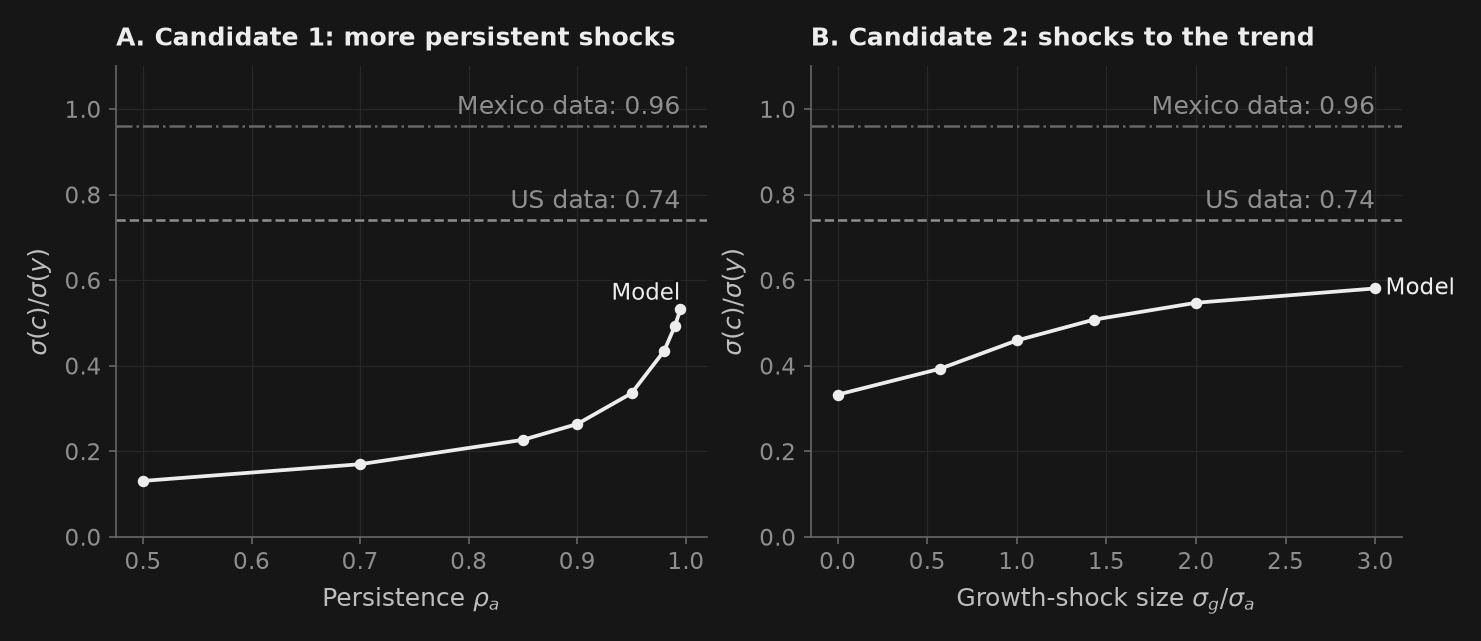

CANDIDATE 1 -- PERSISTENCE OF THE TRANSITORY SHOCK:
 rho_a  sigma(y) %  sigma(c)/sigma(y)  sigma(i)/sigma(y)  corr(c, y)
 0.500       1.110              0.131              4.059       0.521
 0.700       1.209              0.170              3.958       0.606
 0.850       1.300              0.227              3.762       0.739
 0.900       1.309              0.264              3.615       0.811
 0.950       1.273              0.336              3.324       0.902
 0.980       1.202              0.435              2.944       0.958
 0.990       1.171              0.494              2.728       0.973
 0.995       1.172              0.532              2.590       0.980

CANDIDATE 2 -- SHOCKS TO THE GROWTH RATE (Aguiar-Gopinath):
 sigma_g / sigma_a  sigma(y) %  sigma(c)/sigma(y)  sigma(i)/sigma(y)  corr(c, y)
             0.000       1.253              0.333              3.325       0.906
             0.571       1.377              0.393              3.199       0.890
             1.000     

In [11]:
# ==============================================================================
# Candidate 1: Shock Persistence -- Candidate 2: Shocks to the Growth Rate
# ==============================================================================
rho_grid = [0.50, 0.70, 0.85, 0.90, 0.95, 0.98, 0.99, 0.995]
rho_rows = []
for rho_v in rho_grid:
    # Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
        m_rho = load_mod(rbc_mod_path, params={"mu": ss_rbc["mu"], "rho_a": rho_v})
    cyc_rho = filtered_cycles(m_rho, periods=2000, seed=515)
    s_rho = cyc_rho.std()
    rho_rows.append({"rho_a": rho_v, "sigma(y) %": s_rho["y"],
                     "sigma(c)/sigma(y)": s_rho["c"] / s_rho["y"],
                     "sigma(i)/sigma(y)": s_rho["i"] / s_rho["y"],
                     "corr(c, y)": cyc_rho["c"].corr(cyc_rho["y"])})
rho_df = pd.DataFrame(rho_rows)

# Aguiar-Gopinath: stationary model in units of the stochastic trend Gamma_t
trend_shock_mod = f"""
var y c k l i w r a g;
varexo e_a e_g;

parameters alpha beta delta mu nu rho_a rho_g;
alpha   = 0.33;
beta    = 0.99;
delta   = 0.025;
mu      = {ss_rbc['mu']!r};
nu      = 1.5;
rho_a   = 0.95;
rho_g   = 0.30;

model;
mu * (1 - l)^(-nu) * c = w;
c(+1)*exp(g(+1))/(beta*c) = r(+1) + 1 - delta;
r = alpha * y * exp(g) / k(-1);
w = (1 - alpha) * y / l;
y = exp(a) * (k(-1)*exp(-g))^alpha * l^(1-alpha);
y = c + i;
k = (1 - delta)*k(-1)*exp(-g) + i;
a = rho_a * a(-1) + e_a;
g = rho_g * g(-1) + e_g;
end;

initval;
y = {ss_rbc['y']!r};
c = {ss_rbc['c']!r};
i = {ss_rbc['i']!r};
k = {ss_rbc['k']!r};
l = {ss_rbc['l']!r};
w = {ss_rbc['w']!r};
r = {ss_rbc['r']!r};
a = 0.0;
g = 0.0;
end;

shocks;
var e_a; stderr 0.007;
var e_g; stderr 0.007;
end;
"""

# Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_trend = load_mod(trend_shock_mod)
assert m_trend.solution.eu == (1, 1), "The trend-shock model must have a unique stable equilibrium."


def trend_cycles(sd_g, periods=2000, seed=808):
    """Rebuild observed (non-detrended) log series by adding back the stochastic trend."""
    raw = m_trend.simulate(periods=periods, seed=seed, burn=300, sigma={"e_a": 0.007, "e_g": float(sd_g)})
    log_gamma = np.cumsum(raw["g"].values) * 100.0
    logs = {v: 100.0 * np.log((SS_LEVELS[v] + raw[v].values) / SS_LEVELS[v]) + log_gamma for v in ("y", "c", "i")}
    logs["l"] = 100.0 * np.log((SS_LEVELS["l"] + raw["l"].values) / SS_LEVELS["l"])
    return pd.DataFrame({v: hp_filter(pd.Series(s), lamb=1600.0)[0].values for v, s in logs.items()})


sigma_g_grid = [0.0, 0.004, 0.007, 0.010, 0.014, 0.021]
trend_rows = []
for sd_g in sigma_g_grid:
    cyc_g = trend_cycles(sd_g)
    s_g = cyc_g.std()
    trend_rows.append({"sigma_g / sigma_a": sd_g / 0.007, "sigma(y) %": s_g["y"],
                       "sigma(c)/sigma(y)": s_g["c"] / s_g["y"],
                       "sigma(i)/sigma(y)": s_g["i"] / s_g["y"],
                       "corr(c, y)": cyc_g["c"].corr(cyc_g["y"])})
trend_df = pd.DataFrame(trend_rows)

fig, (ax_rho, ax_trend) = _nbstyle.figura(1, 2)

for ax, xdata, ydata, xlabel, title in (
    (ax_rho, rho_df["rho_a"], rho_df["sigma(c)/sigma(y)"], r"Persistence $\rho_a$",
     "A. Candidate 1: more persistent shocks"),
    (ax_trend, trend_df["sigma_g / sigma_a"], trend_df["sigma(c)/sigma(y)"],
     r"Growth-shock size $\sigma_g / \sigma_a$", "B. Candidate 2: shocks to the trend"),
):
    ax.plot(xdata, ydata, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.8, ls="-", marker="o", markersize=4.5, label="Model")
    ax.axhline(0.74, color=_nbstyle.NOTA, ls="--", lw=1.2)
    ax.axhline(0.96, color=_nbstyle.SPINE, ls="-.", lw=1.2)
    for nivel, texto in ((0.74, "US data: 0.74"), (0.96, "Mexico data: 0.96")):
        ax.annotate(texto, xy=(float(xdata.max()), nivel), xytext=(0, 3), textcoords="offset points",
                    ha="right", va="bottom", color=_nbstyle.NOTA)
    ax.set_ylim(0.0, 1.1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\sigma(c)/\sigma(y)$")
    _nbstyle.etiquetar(ax)

plt.show()

print("CANDIDATE 1 -- PERSISTENCE OF THE TRANSITORY SHOCK:")
print(rho_df.round(3).to_string(index=False))
print("\nCANDIDATE 2 -- SHOCKS TO THE GROWTH RATE (Aguiar-Gopinath):")
print(trend_df.round(3).to_string(index=False))

best_rho = float(rho_df["sigma(c)/sigma(y)"].max())
best_trend = float(trend_df["sigma(c)/sigma(y)"].max())
print(f"\nBaseline (rho_a = 0.95, no trend shock): sigma(c)/sigma(y) = {rho_df.loc[4, 'sigma(c)/sigma(y)']:.2f}")
print(f"Best achievable with persistence alone  : {best_rho:.2f} (at rho_a = 0.995, a near-random walk)")
print(f"Best achievable with trend shocks       : {best_trend:.2f} (at sigma_g = 3x sigma_a)")
print("Neither reaches the US 0.74, let alone Mexico's 0.96 -- in a closed economy c + i = y binds every quarter.")

assert best_rho > 1.4 * rho_df.loc[4, "sigma(c)/sigma(y)"], "Persistence must raise consumption volatility substantially."
assert best_trend > best_rho, "Shocks to the trend must beat persistence within the stationary family."
assert best_trend < 0.74, "A closed economy must still fall short of the US consumption-volatility ratio."
print("\nConsumption-smoothing assertions passed: the remaining gap is an open-economy question, not a calibration one.")

## Empirical State-Space Recovery: Kalman Smoothing & Shock Decomposition Across Crisis Episodes

Calibration and stochastic simulation evaluate whether an RBC economy *can* replicate unconditional moments under theoretical shock distributions. A distinct empirical question is: **what unobserved structural trajectory did the economy actually traverse during historical crises?**

Because capital stock $k_t$ and Solow innovations $e_{a,t}$ are not directly observed in national accounts at quarterly frequency, extracting them requires inverting the model's state-space representation through the Kalman smoother (Hamilton 1994, Durbin & Koopman 2012). For a solved linear DSGE:
$$x_t = A x_{t-1} + B \varepsilon_t$$
$$y_t = d + Z x_t + \eta_t$$

`puremacro.dsge.LinearModel.smoother(data, varobs=...)` computes the two-sided conditional expectations $\mathbb{E}[x_t \mid \mathcal{Y}_T]$ and structural shocks $\mathbb{E}[\varepsilon_t \mid \mathcal{Y}_T]$ across the entire historical sample $\mathcal{Y}_T = \{y_1, \dots, y_T\}$. In addition, `sm.shock_decomposition()` decomposes the historical path of each observable into:
$$y_t = y_{ss} + \text{Initial Condition}_t + \sum_{s \le t} \mathcal{H}_{t-s} \varepsilon_s + \text{residual}_t$$

Below, we feed observed US real GDP into the canonical RBC model across the 2005Q1–2024Q4 window, isolating the structural Solow residuals during two defining macroeconomic episodes: the **2008 Great Financial Crisis (GFC)** and the **2020 COVID-19 pandemic shutdown**. From the terminal filtered state $(\hat{x}_T, P_T)$, `LinearModel.forecast(horizon=12)` projects forward dynamic model-consistent fan charts with 90% confidence bands driven by structural shock uncertainty.

KALMAN SMOOTHING: HISTORICAL CRISIS EPISODE SHOCK EXTRACTION
2008Q4 Great Financial Crisis (Lehman) TFP Shock e_a :  -1.69%
2020Q2 COVID-19 Pandemic Lockdown TFP Shock e_a      :  -6.37%
Terminal Filtered Capital Stock (k_T dev)             : +0.0033


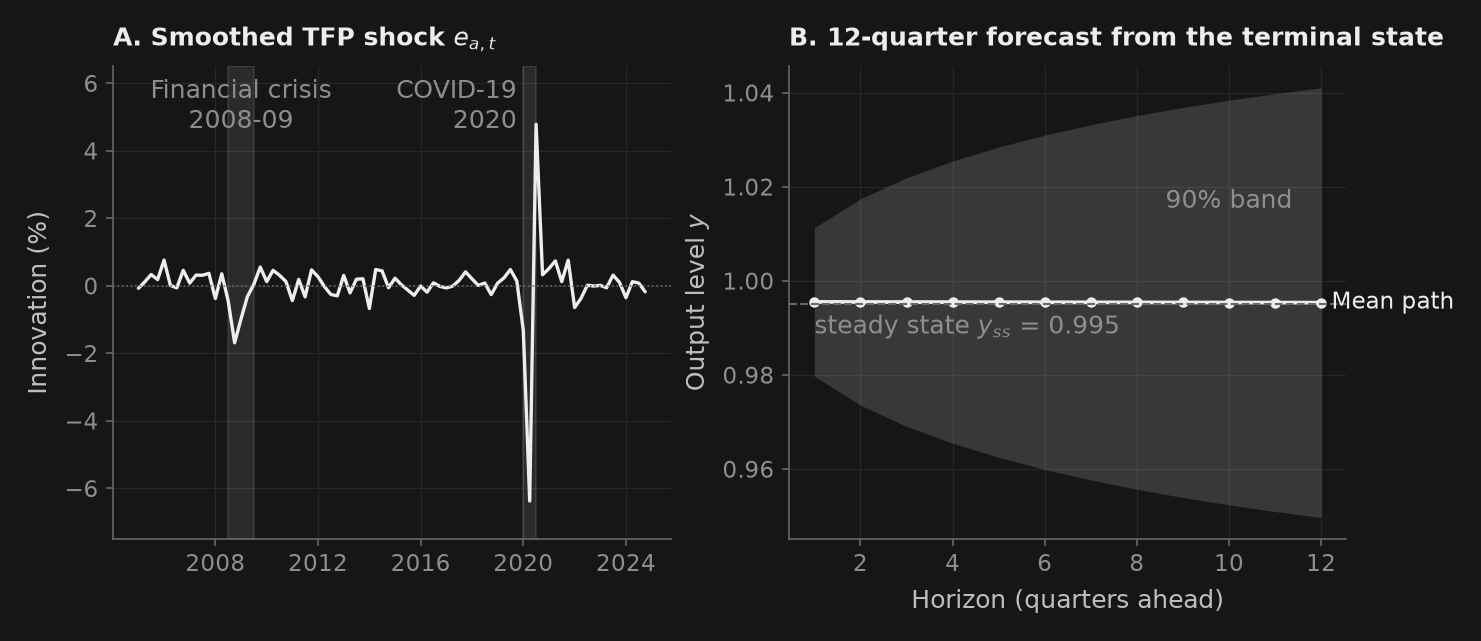


Kalman smoother and dynamic forecasting assertions successfully passed!


In [12]:
# ==============================================================================
# Empirical State-Space Recovery: Kalman Smoothing & Dynamic Forecasting
# ==============================================================================
# 1. Load historical quarterly US real GDP
gdp_data_path = ruta_dato("GDPC1.csv")

gdp_df = pd.read_csv(gdp_data_path)
gdp_df["date"] = pd.to_datetime(gdp_df["observation_date"])
gdp_df = gdp_df.set_index("date").sort_index()

# Extract 2005Q1 to 2024Q4 crisis window (covering 2008 GFC and 2020 COVID-19)
hist_sample = gdp_df.loc["2005-01-01":"2024-10-01"].copy()
cycle_gdp, _ = hp_filter(np.log(hist_sample["GDPC1"]), lamb=1600.0)
hist_sample["cycle"] = cycle_gdp

# Center observable on model steady-state level
y_ss = float(m_rbc.steady_state["y"])
hist_sample["y"] = y_ss * (1.0 + hist_sample["cycle"])
data_rbc = hist_sample[["y"]]

# 2. Kalman Smoothing
sm_rbc = m_rbc.smoother(data_rbc, varobs=["y"])

# 3. Dynamic DSGE Forecasting across H=12 quarters from terminal filtered state
fc_rbc = m_rbc.forecast(horizon=12, data=data_rbc, varobs=["y"], ci=0.90)

# 4. Crisis Episode Diagnostics
gfc_shock = float(sm_rbc.shocks.loc["2008-10-01", "e_a"])
covid_shock = float(sm_rbc.shocks.loc["2020-04-01", "e_a"])

print("=" * 76)
print("KALMAN SMOOTHING: HISTORICAL CRISIS EPISODE SHOCK EXTRACTION")
print("=" * 76)
print(f"2008Q4 Great Financial Crisis (Lehman) TFP Shock e_a : {gfc_shock * 100:+6.2f}%")
print(f"2020Q2 COVID-19 Pandemic Lockdown TFP Shock e_a      : {covid_shock * 100:+6.2f}%")
print(f"Terminal Filtered Capital Stock (k_T dev)             : {sm_rbc.states['k'].iloc[-1]:+6.4f}")
print("=" * 76)

# 5. Visualizing Historical Smoothed Innovations and Forward Fan Chart
fig, (ax_shk, ax_fc) = _nbstyle.figura(1, 2)

# Panel A: Historical Smoothed TFP Shocks
ax_shk.plot(sm_rbc.shocks.index, sm_rbc.shocks["e_a"] * 100.0, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
ax_shk.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_shk.axvspan(pd.Timestamp("2008-07-01"), pd.Timestamp("2009-06-30"), color=_nbstyle.RECESION)
ax_shk.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-07-01"), color=_nbstyle.RECESION)
ax_shk.set_ylim(-7.5, 6.5)
ax_shk.text(pd.Timestamp("2009-01-01"), 6.2, "Financial crisis\n2008-09", ha="center", va="top", color=_nbstyle.NOTA)
ax_shk.text(pd.Timestamp("2019-10-01"), 6.2, "COVID-19\n2020", ha="right", va="top", color=_nbstyle.NOTA)
ax_shk.set_title("A. Smoothed TFP shock $e_{a,t}$")
ax_shk.set_ylabel("Innovation (%)")

# Panel B: DSGE Fan Chart Forecast
h_axis = np.arange(1, 13)
y_mean = fc_rbc.mean["y"].values
y_low = fc_rbc.lower["y"].values
y_upp = fc_rbc.upper["y"].values

ax_fc.plot(h_axis, y_mean, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.8, ls="-", marker="o", markersize=4, label="Mean path")
ax_fc.fill_between(h_axis, y_low, y_upp, color=_nbstyle.BANDA, lw=0)
ax_fc.axhline(y_ss, color=_nbstyle.SPINE, ls="--", lw=1.0)
ax_fc.annotate(f"steady state $y_{{ss}}$ = {y_ss:.3f}", xy=(h_axis[0], y_ss), xytext=(0, -5), textcoords="offset points",
               ha="left", va="top", color=_nbstyle.NOTA)
ax_fc.text(h_axis[-3], (y_mean[-3] + y_upp[-3]) / 2, "90% band", ha="center", va="center", color=_nbstyle.NOTA)
ax_fc.set_title("B. 12-quarter forecast from the terminal state")
ax_fc.set_xlabel("Horizon (quarters ahead)")
ax_fc.set_ylabel("Output level $y$")
_nbstyle.etiquetar(ax_fc)

plt.show()

# Verification Assertions
assert gfc_shock < -0.015, f"GFC shock should be contractionary: {gfc_shock}"
assert covid_shock < -0.05, f"COVID shock should be extreme contraction: {covid_shock}"
assert (fc_rbc.lower["y"] < fc_rbc.mean["y"]).all(), "Lower forecast band must be strictly below mean path."
assert (fc_rbc.upper["y"] > fc_rbc.mean["y"]).all(), "Upper forecast band must be strictly above mean path."
print("\nKalman smoother and dynamic forecasting assertions successfully passed!")

## Bayesian and Mode Estimation: Declarative Calibration Confrontation

Macroeconomic practice rarely rests solely on calibrated parameters; modern macroeconometrics disciplines deep structural elasticities using likelihood-based estimation (An & Schorfheide 2007, Fernández-Villaverde 2010, Herbst & Schorfheide 2015).

`puremacro.dsge.LinearModel.estimate` connects declarative Dynare `.mod` files directly to numerical mode finding and Random Walk Metropolis-Hastings (RWMH) MCMC posterior sampling:
1. **Declarative Priors**: In the `.mod` file, the `varobs` statement specifies the observable series, while `estimated_params; ... end;` defines the parameter prior distributions (e.g., Beta for persistence $\rho_a \in (0, 1)$, Inverse-Gamma for standard errors $\sigma_a > 0$).
2. **Automatic State-Space Likelihood**: The solver constructs the observation matrices mapping latent states to observables, evaluating the exact Gaussian log-likelihood via the Kalman filter.
3. **Posterior Diagnostics & Model Comparison**: The posterior result (`DSGEPosteriorResult`) provides the posterior mode, MCMC posterior draws, parameter quantiles, and the **Laplace marginal data density** $\log p(\mathcal{Y})$, allowing formal Bayesian model comparison and odds ratios.

Below, we estimate the TFP persistence $\rho_a$ and innovation volatility $\sigma_a$ on the empirical US real GDP series, confronting the textbook Kydland-Prescott calibration ($\rho_a = 0.95, \sigma_a = 0.007$) with data.

In [13]:
# ==============================================================================
# Bayesian and Mode Estimation via Declarative .mod Declarations
# ==============================================================================
# Construct declarative estimation specification with varobs and estimated_params
rbc_estim_mod_text = Path(rbc_mod_path).read_text() + """
varobs y;
estimated_params;
  rho_a, beta_pdf, 0.90, 0.05;
  stderr e_a, inv_gamma_pdf, 0.01, 2;
end;
"""

# Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_rbc_est = load_mod(rbc_estim_mod_text)

# Execute Bayesian MCMC estimation (RWMH with mode-based Laplace proposal)
print("Estimating RBC structural parameters via puremacro MCMC...")
# Harmless: puremacro's steady-state solver probes the call signature at l = 1, where (1-l)^(-nu) = 0^(-nu); that value is discarded
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    res_rbc_est = m_rbc_est.estimate(data_rbc, n_draws=600, n_chains=2, burn_in=150, seed=42)

print("\n" + "=" * 76)
print("DSGE BAYESIAN ESTIMATION SUMMARY REPORT")
print("=" * 76)
print("Posterior Mode:")
for p_name, p_val in res_rbc_est.mode.items():
    print(f"  {p_name:<16}: {p_val:.6f}")

print("\nPosterior Moments and Credible Intervals:")
summary_table = res_rbc_est.summary()
print(summary_table.round(5))

log_mdd_laplace = res_rbc_est.log_mdd("laplace")
print(f"\nLaplace Marginal Data Density log p(Y) : {log_mdd_laplace:.4f}")
print("=" * 76)

# Verification Assertions
assert 0.50 < res_rbc_est.mode["rho_a"] < 1.0, f"Estimated rho_a out of bounds: {res_rbc_est.mode['rho_a']}"
assert 0.003 < res_rbc_est.mode["SE_e_a"] < 0.025, f"Estimated SE_e_a out of bounds: {res_rbc_est.mode['SE_e_a']}"
assert np.isfinite(log_mdd_laplace), "Laplace log marginal data density must be finite."
print("\nBayesian estimation assertions successfully passed!")

Estimating RBC structural parameters via puremacro MCMC...



DSGE BAYESIAN ESTIMATION SUMMARY REPORT
Posterior Mode:
  rho_a           : 0.994140
  SE_e_a          : 0.008908

Posterior Moments and Credible Intervals:
           mean      std       q5      q50      q95     mode
rho_a   0.99203  0.00345  0.98520  0.99250  0.99665  0.99414
SE_e_a  0.00912  0.00067  0.00801  0.00909  0.01021  0.00891

Laplace Marginal Data Density log p(Y) : 215.4795

Bayesian estimation assertions successfully passed!
